# 12 - Shared LSTM vs XGBoost Comparison

Report-ready reload flow for thesis reporting. This notebook now defaults to validated CSV artifacts under `results/report_ready_20260405/`, keeps the `M0-M4` and `FW0-FW2` taxonomy explicit, and treats pooled training as supplementary building-level evaluation rather than a primary headline result.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import subprocess
import sys
from pathlib import Path


def ensure_runtime_packages(dep_to_package: dict[str, str]) -> None:
    missing_packages = [pkg for mod, pkg in dep_to_package.items() if importlib.util.find_spec(mod) is None]
    if missing_packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])
        importlib.invalidate_caches()


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    project_root_override = os.environ.get('THESIS_PROJECT_ROOT', '').strip()

    candidates: list[Path] = []
    if project_root_override:
        candidates.append(Path(project_root_override).expanduser())
    candidates.extend([cwd, cwd / 'thesis-project', cwd.parent / 'thesis-project'])

    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'data' / 'features' / 'feature_metadata.csv').exists():
            return candidate

    raise FileNotFoundError(
        'Could not locate the thesis-project root. Set THESIS_PROJECT_ROOT or start the runtime '
        'in the project directory so that `data/features/feature_metadata.csv` is available.'
    )


In [2]:
ensure_runtime_packages(
    {
        'numpy': 'numpy',
        'pandas': 'pandas',
        'matplotlib': 'matplotlib',
        'seaborn': 'seaborn',
        'sklearn': 'scikit-learn',
        'xgboost': 'xgboost',
        'tensorflow': 'tensorflow',
    }
)

PROJECT_ROOT = resolve_project_root()
os.environ['THESIS_PROJECT_ROOT'] = str(PROJECT_ROOT)
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('MPLCONFIGDIR', str((PROJECT_ROOT / '.mplconfig').resolve()))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Markdown, display

import utils.model_family_comparison as mfc
import utils.model_family_presentation as mfp


def pick_existing_results_dir(candidates: list[Path], artifact_name: str) -> Path:
    for candidate in candidates:
        candidate = Path(candidate).resolve()
        if (candidate / artifact_name).exists():
            return candidate
    raise FileNotFoundError(
        f'Could not find any saved results directory containing `{artifact_name}`. Checked: '
        + ', '.join(str(Path(candidate).resolve()) for candidate in candidates)
    )


REPORT_ROOT = PROJECT_ROOT / 'results' / 'report_ready_20260405'
RAW_RESULTS_DIR = PROJECT_ROOT / 'results' / 'model_family_comparison_29032026'
MODEL_FAMILY_REPORT_BASE_DIR = REPORT_ROOT / 'model_family_base'
MODEL_FAMILY_REPORT_FINAL_DIR = REPORT_ROOT / 'model_family'
M1_EXTENSION_RESULTS_DIR = PROJECT_ROOT / 'results' / 'model_family_comparison_m1_extension_20260405'
MODEL_FAMILY_M3_SUPPLEMENT_DIR = PROJECT_ROOT / 'results' / 'model_family_comparison_m3_supplement_20260405'
MODEL_FAMILY_REPORT_M3_SUPPLEMENT_DIR = REPORT_ROOT / 'model_family_m3_supplement'
PROFILE_DISABLED_RUN_DIR = PROJECT_ROOT / 'results' / 'model_family_comparison_profile_disabled'
AUTO_EXPORT_REPORT_READY = True

WORKFLOW_PROFILE = 'resume_m3_missing_only'
VALID_WORKFLOW_PROFILES = (
    'base_review',
    'full_matrix_review',
    'resume_m3_missing_only',
)
if WORKFLOW_PROFILE not in VALID_WORKFLOW_PROFILES:
    raise ValueError(f'Unknown WORKFLOW_PROFILE: {WORKFLOW_PROFILE}')

REQUESTED_WEATHER_MODES = ('FW0', 'FW1', 'FW2')
REQUESTED_REGIMES = ('per_building', 'pooled_same_buildings')
DEFAULT_MAIN_MODES = ('M0', 'M1', 'M2', 'M4')
THESIS_FULL_MODES = ('M0', 'M1', 'M2', 'M3', 'M4')

PRIMARY_COMPARISON_RESULTS_DIR = pick_existing_results_dir(
    [MODEL_FAMILY_REPORT_FINAL_DIR, MODEL_FAMILY_REPORT_BASE_DIR, RAW_RESULTS_DIR],
    'comparison_metrics.csv',
)
CANONICAL_SUPERSET_RESULTS_DIR = pick_existing_results_dir(
    [MODEL_FAMILY_REPORT_M3_SUPPLEMENT_DIR, MODEL_FAMILY_M3_SUPPLEMENT_DIR],
    'comparison_metrics.csv',
)
ACTIVE_RESULTS_DIR = CANONICAL_SUPERSET_RESULTS_DIR
ACTIVE_RESULTS_INDEX_DF = pd.read_csv(ACTIVE_RESULTS_DIR / 'comparison_metrics.csv')
PRIMARY_RESULTS_INDEX_DF = pd.read_csv(PRIMARY_COMPARISON_RESULTS_DIR / 'comparison_metrics.csv')

MAIN_BUILDINGS = tuple(sorted(ACTIVE_RESULTS_INDEX_DF['building'].dropna().astype(str).unique().tolist()))
MAIN_HORIZONS = tuple(sorted(ACTIVE_RESULTS_INDEX_DF['horizon_h'].dropna().astype(int).unique().tolist()))
MAIN_REGIMES = tuple(regime for regime in REQUESTED_REGIMES if regime in set(ACTIVE_RESULTS_INDEX_DF['regime'].astype(str)))
MAIN_WEATHER_MODES = tuple(mode for mode in REQUESTED_WEATHER_MODES if mode in set(ACTIVE_RESULTS_INDEX_DF['weather_mode'].astype(str)))
MAIN_MODES = tuple(mode for mode in THESIS_FULL_MODES if mode in set(ACTIVE_RESULTS_INDEX_DF['mode'].astype(str)))
if not MAIN_REGIMES:
    MAIN_REGIMES = REQUESTED_REGIMES
if not MAIN_WEATHER_MODES:
    MAIN_WEATHER_MODES = REQUESTED_WEATHER_MODES
if not MAIN_MODES:
    MAIN_MODES = THESIS_FULL_MODES

PROFILE_SETTINGS = {
    'base_review': {
        'run_full_matrix': False,
        'full_run_results_dir': PROFILE_DISABLED_RUN_DIR,
        'load_source_results_dir': PRIMARY_COMPARISON_RESULTS_DIR,
        'merge_source_results_dirs': (),
        'run_modes': DEFAULT_MAIN_MODES,
        'run_weather_modes': REQUESTED_WEATHER_MODES,
        'run_regimes': REQUESTED_REGIMES,
        'run_horizons': MAIN_HORIZONS,
        'requested_main_modes': DEFAULT_MAIN_MODES,
        'requested_transition_pairs': (('M1', 'M0'), ('M2', 'M0'), ('M4', 'M2')),
        'notebook_report_export_dir': MODEL_FAMILY_REPORT_FINAL_DIR,
        'present_feature_effect_modes': ('M0', 'M1', 'M2', 'M4'),
        'manifest_strategy': 'profile_scope',
    },
    'full_matrix_review': {
        'run_full_matrix': False,
        'full_run_results_dir': PROFILE_DISABLED_RUN_DIR,
        'load_source_results_dir': CANONICAL_SUPERSET_RESULTS_DIR,
        'merge_source_results_dirs': (),
        'run_modes': THESIS_FULL_MODES,
        'run_weather_modes': REQUESTED_WEATHER_MODES,
        'run_regimes': REQUESTED_REGIMES,
        'run_horizons': MAIN_HORIZONS,
        'requested_main_modes': THESIS_FULL_MODES,
        'requested_transition_pairs': (('M1', 'M0'), ('M2', 'M0'), ('M3', 'M2'), ('M4', 'M3')),
        'notebook_report_export_dir': MODEL_FAMILY_REPORT_M3_SUPPLEMENT_DIR,
        'present_feature_effect_modes': ('M2', 'M3', 'M4'),
        'manifest_strategy': 'thesis_full_matrix',
    },
    'resume_m3_missing_only': {
        'run_full_matrix': True,
        'full_run_results_dir': MODEL_FAMILY_M3_SUPPLEMENT_DIR,
        'load_source_results_dir': CANONICAL_SUPERSET_RESULTS_DIR,
        'merge_source_results_dirs': (RAW_RESULTS_DIR, M1_EXTENSION_RESULTS_DIR, MODEL_FAMILY_M3_SUPPLEMENT_DIR),
        'run_modes': ('M3',),
        'run_weather_modes': REQUESTED_WEATHER_MODES,
        'run_regimes': REQUESTED_REGIMES,
        'run_horizons': MAIN_HORIZONS,
        'requested_main_modes': THESIS_FULL_MODES,
        'requested_transition_pairs': (('M1', 'M0'), ('M2', 'M0'), ('M3', 'M2'), ('M4', 'M3')),
        'notebook_report_export_dir': MODEL_FAMILY_REPORT_M3_SUPPLEMENT_DIR,
        'present_feature_effect_modes': ('M2', 'M3', 'M4'),
        'manifest_strategy': 'missing_only',
    },
}

PROFILE = PROFILE_SETTINGS[WORKFLOW_PROFILE]
PIPELINE_RUN_PROFILES = tuple(PROFILE.get('run_sequence', (WORKFLOW_PROFILE,) if bool(PROFILE['run_full_matrix']) else ()))
PIPELINE_EXPORT_PROFILES = tuple(PROFILE.get('export_sequence', (WORKFLOW_PROFILE,)))
PRIMARY_RUN_PROFILE = PROFILE_SETTINGS[PIPELINE_RUN_PROFILES[0]] if PIPELINE_RUN_PROFILES else PROFILE
RUN_FULL_MATRIX_IN_NOTEBOOK = bool(PROFILE['run_full_matrix'])
FULL_RUN_RESULTS_DIR = Path(PRIMARY_RUN_PROFILE['full_run_results_dir']).resolve()
LOAD_SOURCE_RESULTS_DIR = Path(PROFILE['load_source_results_dir']).resolve()
MERGE_SOURCE_RESULTS_DIRS = tuple(Path(path).resolve() for path in PROFILE['merge_source_results_dirs'])
RUN_BUILDINGS = MAIN_BUILDINGS
RUN_HORIZONS = tuple(int(h) for h in PRIMARY_RUN_PROFILE['run_horizons'])
RUN_REGIMES = tuple(PRIMARY_RUN_PROFILE['run_regimes'])
RUN_WEATHER_MODES = tuple(PRIMARY_RUN_PROFILE['run_weather_modes'])
RUN_MODES = tuple(PRIMARY_RUN_PROFILE['run_modes'])
REQUESTED_MAIN_MODES = tuple(PROFILE['requested_main_modes'])
REQUESTED_TRANSITION_PAIRS = tuple(tuple(pair) for pair in PROFILE['requested_transition_pairs'])
NOTEBOOK_LOAD_RESULTS_DIR = LOAD_SOURCE_RESULTS_DIR
NOTEBOOK_REPORT_EXPORT_DIR = Path(PROFILE['notebook_report_export_dir']).resolve()
PRESENT_FEATURE_EFFECT_MODES = tuple(PROFILE['present_feature_effect_modes'])
MANIFEST_STRATEGY = str(PROFILE.get('manifest_strategy', 'profile_scope'))

PREVIEW_BUILDING = 'U05' if 'U05' in MAIN_BUILDINGS else MAIN_BUILDINGS[0]
PREVIEW_MODE = 'M3' if 'M3' in REQUESTED_MAIN_MODES else ('M4' if 'M4' in REQUESTED_MAIN_MODES else REQUESTED_MAIN_MODES[-1])
PREVIEW_WEATHER = 'FW2' if 'FW2' in REQUESTED_WEATHER_MODES else REQUESTED_WEATHER_MODES[-1]
PREVIEW_HORIZON = 24 if 24 in MAIN_HORIZONS else MAIN_HORIZONS[-1]

RUN_SANITY_SMOKE = False
REQUIRE_SANITY_PASS = True
SANITY_BUILDING = PREVIEW_BUILDING
SANITY_MODE = 'M3' if 'M3' in RUN_MODES else RUN_MODES[0]
SANITY_WEATHER = 'FW0' if 'FW0' in RUN_WEATHER_MODES else RUN_WEATHER_MODES[0]
SANITY_HORIZON = 8 if 8 in RUN_HORIZONS else RUN_HORIZONS[0]
RESUME_EXISTING = True
SAVE_AFTER_EACH_PAIR = True
CONTINUE_ON_ERROR = True

LOOKBACK_HOURS = 72
LSTM_BATCH_SIZE = 256
LSTM_EPOCHS = 50
LSTM_EARLY_STOPPING_PATIENCE = 3
LSTM_LEARNING_RATE = 1e-3
LSTM_DETERMINISTIC_OPS = False
RANDOM_SEED = 42

FOCUS_REGIME = 'per_building'
FOCUS_MODE = PREVIEW_MODE
FOCUS_WEATHER = PREVIEW_WEATHER
FOCUS_H = PREVIEW_HORIZON
FOCUS_BUILDING = PREVIEW_BUILDING

PRESENT_BUILDING = PREVIEW_BUILDING
PRESENT_MODE = FOCUS_MODE
PRESENT_WEATHER = FOCUS_WEATHER
PRESENT_FAMILY = 'lstm'
PRESENT_HORIZON = FOCUS_H
PRESENT_HORIZONS = tuple(h for h in (1, 4, 8, 24) if h in MAIN_HORIZONS) or (MAIN_HORIZONS[0],)
PRESENT_SEASON = 'winter'

config = mfc.ExperimentConfig(
    buildings=MAIN_BUILDINGS,
    horizons=MAIN_HORIZONS,
    regimes=MAIN_REGIMES,
    weather_modes=MAIN_WEATHER_MODES,
    modes=MAIN_MODES,
    lookback_hours=LOOKBACK_HOURS,
    results_dir=LOAD_SOURCE_RESULTS_DIR,
    lstm_architecture_id='A6',
    xgb_preset_id='P01_md3_lr003_mc5',
    random_seed=RANDOM_SEED,
    batch_size=LSTM_BATCH_SIZE,
    epochs=LSTM_EPOCHS,
    early_stopping_patience=LSTM_EARLY_STOPPING_PATIENCE,
    learning_rate=LSTM_LEARNING_RATE,
    deterministic_ops=LSTM_DETERMINISTIC_OPS,
)

outputs = None
saved_outputs = None
current_outputs = None
exported_report_tables = {}
export_registry_df = pd.DataFrame()
base_frames = None
manifest_df = None
desired_full_manifest_df = pd.DataFrame()
current_manifest_df = pd.DataFrame()
primary_manifest_df = pd.DataFrame()
comparison_inventory_df = pd.DataFrame()
comparison_inventory_summary_df = pd.DataFrame()
comparison_missing_manifest_df = pd.DataFrame()
comparison_overlap_df = pd.DataFrame()
planned_run_manifest_df = pd.DataFrame()
planned_run_manifest_map = {}
planned_run_stage_scope_df = pd.DataFrame()
comparison_ready = False
metrics_df = pd.DataFrame()
summary_df = pd.DataFrame()
summary_report_df = pd.DataFrame()
thesis_per_building_df = pd.DataFrame()
thesis_pooled_df = pd.DataFrame()
predictions_df = pd.DataFrame()
coverage_df = pd.DataFrame()
run_log_df = pd.DataFrame()
run_log_latest_df = pd.DataFrame()
lstm_history_df = pd.DataFrame()
xgb_history_df = pd.DataFrame()
mode_semantics_df = pd.DataFrame()
weather_mode_semantics_df = pd.DataFrame()
metric_validation_df = pd.DataFrame()
notebook_validation_df = pd.DataFrame()
SEASON_WINDOWS = None

runtime_df = pd.DataFrame(
    [
        {'field': 'project_root', 'value': str(PROJECT_ROOT)},
        {'field': 'workflow_profile', 'value': WORKFLOW_PROFILE},
        {'field': 'primary_comparison_results_dir', 'value': str(PRIMARY_COMPARISON_RESULTS_DIR)},
        {'field': 'canonical_superset_results_dir', 'value': str(CANONICAL_SUPERSET_RESULTS_DIR)},
        {'field': 'load_source_results_dir', 'value': str(LOAD_SOURCE_RESULTS_DIR)},
        {'field': 'full_run_results_dir', 'value': str(FULL_RUN_RESULTS_DIR)},
        {'field': 'notebook_report_export_dir', 'value': str(NOTEBOOK_REPORT_EXPORT_DIR)},
        {'field': 'manifest_strategy', 'value': MANIFEST_STRATEGY},
        {'field': 'run_modes', 'value': ', '.join(RUN_MODES)},
        {'field': 'requested_main_modes', 'value': ', '.join(REQUESTED_MAIN_MODES)},
        {'field': 'run_weather_modes', 'value': ', '.join(RUN_WEATHER_MODES)},
        {'field': 'run_regimes', 'value': ', '.join(RUN_REGIMES)},
        {'field': 'run_horizons', 'value': ', '.join(str(h) for h in RUN_HORIZONS)},
        {'field': 'resume_existing', 'value': str(RESUME_EXISTING)},
    ]
)
display(Markdown('### Runtime configuration'))
display(runtime_df)


### Runtime configuration

,field,value
0,project_root,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
1,workflow_profile,resume_m3_missing_only
2,primary_comparison_results_dir,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
3,canonical_superset_results_dir,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
4,load_source_results_dir,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
5,full_run_results_dir,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
6,notebook_report_export_dir,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
7,manifest_strategy,missing_only
8,run_modes,M3
9,requested_main_modes,"M0, M1, M2, M3, M4"


## Project Setup

Run the next cells in order the first time. After artifacts exist, you can jump directly to the saved-output and plotting sections.


In [3]:
paths = mfc.ensure_results_dirs(config)
artifact_df = pd.DataFrame(
    [{'artifact': key, 'path': str(path)} for key, path in paths.items()]
)
display(Markdown('### Artifact locations'))
display(artifact_df)


### Artifact locations

,artifact,path
0,results,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
1,plots,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
2,manifest,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
3,predictions,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
4,metrics,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
5,summary,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
6,coverage,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
7,run_log,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
8,lstm_history,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
9,xgb_history,/Users/mihkeluutar/Documents/TalTech/Thesis/th...


## Quick Smoke Check

Run this cheap preflight before any heavier notebook cells. It only checks the active kernel and saved artifact state.


In [4]:
smoke_rows = [
    {'check': 'kernel_python', 'status': 'ok' if 'thesis-project/.venv' in sys.executable else 'warn', 'detail': sys.executable},
    {'check': 'active_results_dir_exists', 'status': 'ok' if ACTIVE_RESULTS_DIR.exists() else 'block', 'detail': str(ACTIVE_RESULTS_DIR)},
    {'check': 'notebook_load_results_dir_exists', 'status': 'ok' if NOTEBOOK_LOAD_RESULTS_DIR.exists() else 'warn', 'detail': str(NOTEBOOK_LOAD_RESULTS_DIR)},
]
for name in ['comparison_metrics.csv', 'comparison_predictions.csv', 'comparison_summary.csv']:
    path = ACTIVE_RESULTS_DIR / name
    smoke_rows.append({'check': name, 'status': 'ok' if path.exists() else 'block', 'detail': str(path)})
metric_validation_path = NOTEBOOK_REPORT_EXPORT_DIR / 'metric_recompute_validation.csv'
if metric_validation_path.exists():
    metric_validation_probe_df = pd.read_csv(metric_validation_path)
    smoke_rows.append({
        'check': 'metric_validation_matches',
        'status': 'ok' if metric_validation_probe_df.get('matches_within_1e-9', pd.Series(dtype=bool)).fillna(False).all() else 'warn',
        'detail': f'rows={len(metric_validation_probe_df)} path={metric_validation_path}',
    })
smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df)


,check,status,detail
0,kernel_python,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
1,active_results_dir_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
2,notebook_load_results_dir_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
3,comparison_metrics.csv,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
4,comparison_predictions.csv,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
5,comparison_summary.csv,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
6,metric_validation_matches,ok,rows=4 path=/Users/mihkeluutar/Documents/TalTe...


In [5]:
base_frames = mfc.build_base_frame_cache(config)
base_frame_overview_df = pd.DataFrame(
    [
        {
            'building': building,
            'setA_rows': len(frame_map['setA']),
            'setB_rows': len(frame_map['setB']),
            'setA_cols': len(frame_map['setA'].columns),
            'setB_cols': len(frame_map['setB'].columns),
        }
        for building, frame_map in base_frames.items()
    ]
).sort_values('building').reset_index(drop=True)
display(Markdown('### Base-frame cache overview'))
display(base_frame_overview_df)


### Base-frame cache overview

,building,setA_rows,setB_rows,setA_cols,setB_cols
0,LIB,22954,22954,379,469
1,SOC,22954,22954,379,469
2,U02B,22925,22925,379,469
3,U03,22925,22925,379,469
4,U05,25206,25206,379,469
5,U06,25206,25206,379,469


In [6]:
full_matrix_config = mfc.clone_experiment_config(
    config,
    buildings=MAIN_BUILDINGS,
    horizons=MAIN_HORIZONS,
    regimes=REQUESTED_REGIMES,
    weather_modes=REQUESTED_WEATHER_MODES,
    modes=THESIS_FULL_MODES,
)
desired_full_manifest_df = mfc.build_comparison_manifest(full_matrix_config)

current_manifest_path = CANONICAL_SUPERSET_RESULTS_DIR / 'comparison_manifest.csv'
current_manifest_df = pd.read_csv(current_manifest_path) if current_manifest_path.exists() else pd.DataFrame()
if current_manifest_df.empty:
    current_manifest_df = mfc.load_saved_outputs(
        mfc.clone_experiment_config(config, results_dir=CANONICAL_SUPERSET_RESULTS_DIR)
    ).manifest_df.copy()

primary_manifest_path = PRIMARY_COMPARISON_RESULTS_DIR / 'comparison_manifest.csv'
primary_manifest_df = pd.read_csv(primary_manifest_path) if primary_manifest_path.exists() else pd.DataFrame()
if primary_manifest_df.empty:
    primary_manifest_df = mfc.load_saved_outputs(
        mfc.clone_experiment_config(config, results_dir=PRIMARY_COMPARISON_RESULTS_DIR)
    ).manifest_df.copy()

manifest_df = desired_full_manifest_df.copy()
comparison_overlap_df = mfc.comparison_manifest_overlap_report(
    primary_manifest_df,
    current_manifest_df,
    subset_label=str(PRIMARY_COMPARISON_RESULTS_DIR),
    superset_label=str(CANONICAL_SUPERSET_RESULTS_DIR),
)
comparison_inventory_df = mfc.build_comparison_matrix_inventory(
    desired_full_manifest_df,
    current_manifest_df,
    source_dir=CANONICAL_SUPERSET_RESULTS_DIR,
    notebook='12',
    layer='model_family_comparison',
)
comparison_missing_manifest_df = mfc.build_missing_comparison_manifest(
    desired_full_manifest_df,
    current_manifest_df,
)
comparison_inventory_summary_df = (
    comparison_inventory_df.groupby(['status', 'mode', 'regime'], as_index=False)
    .agg(rows=('status', 'size'))
    .sort_values(['status', 'mode', 'regime'])
    .reset_index(drop=True)
)

planned_run_manifest_parts = []
planned_run_stage_rows = []
planned_run_manifest_map = {}
for stage_name in PIPELINE_RUN_PROFILES:
    stage_profile = PROFILE_SETTINGS[stage_name]
    stage_run_config = mfc.clone_experiment_config(
        config,
        buildings=RUN_BUILDINGS,
        horizons=tuple(int(h) for h in stage_profile['run_horizons']),
        regimes=tuple(stage_profile['run_regimes']),
        weather_modes=tuple(stage_profile['run_weather_modes']),
        modes=tuple(stage_profile['run_modes']),
        results_dir=Path(stage_profile['full_run_results_dir']).resolve(),
    )
    stage_manifest_strategy = str(stage_profile.get('manifest_strategy', 'profile_scope'))
    if stage_manifest_strategy == 'missing_only':
        stage_manifest_df = comparison_missing_manifest_df.copy()
    elif stage_manifest_strategy == 'thesis_full_matrix':
        stage_manifest_df = desired_full_manifest_df.copy()
    else:
        stage_manifest_df = mfc.build_comparison_manifest(stage_run_config)
    planned_run_manifest_map[stage_name] = stage_manifest_df.copy()
    planned_run_manifest_parts.append(stage_manifest_df)
    planned_run_stage_rows.append(
        {
            'manifest_kind': f'run_scope::{stage_name}',
            'manifest_strategy': stage_manifest_strategy,
            'manifest_rows': int(len(stage_manifest_df)),
            'pair_slots': int(len(stage_manifest_df) // max(1, len(stage_run_config.model_families))),
        }
    )
planned_run_manifest_df = pd.concat(planned_run_manifest_parts, ignore_index=True) if planned_run_manifest_parts else pd.DataFrame()
planned_run_stage_scope_df = pd.DataFrame(planned_run_stage_rows)
manifest_scope_rows = [
    {
        'manifest_kind': 'desired_full_matrix',
        'manifest_strategy': 'thesis_full_matrix',
        'manifest_rows': int(len(desired_full_manifest_df)),
        'pair_slots': int(len(desired_full_manifest_df) // max(1, len(config.model_families))),
    },
    {
        'manifest_kind': 'completed_now',
        'manifest_strategy': 'current_saved_manifest',
        'manifest_rows': int(len(current_manifest_df)),
        'pair_slots': int(len(current_manifest_df) // max(1, len(config.model_families))),
    },
    {
        'manifest_kind': 'missing_now',
        'manifest_strategy': 'desired_minus_current',
        'manifest_rows': int(len(comparison_missing_manifest_df)),
        'pair_slots': int(len(comparison_missing_manifest_df) // max(1, len(config.model_families))),
    },
]
if not planned_run_stage_scope_df.empty:
    manifest_scope_rows.extend(planned_run_stage_rows)

display(Markdown('### Desired full comparison manifest preview'))
display(desired_full_manifest_df.head(12))
display(Markdown('### Manifest scope summary'))
display(pd.DataFrame(manifest_scope_rows))
display(Markdown('### Primary-vs-superset overlap check'))
display(comparison_overlap_df)
display(Markdown('### Comparison inventory summary'))
display(comparison_inventory_summary_df)
if not comparison_missing_manifest_df.empty:
    display(Markdown('### Missing manifest preview'))
    display(comparison_missing_manifest_df.head(12))


/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/utils/model_family_comparison.py:1201: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inventory["completed_now"] = inventory["completed_now"].fillna(False).astype(bool)
/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/utils/model_family_comparison.py:1158: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  missing = missing.loc[missing["_present"].fillna(False) == False].drop(columns="_present")


### Desired full comparison manifest preview

,regime,building,model_family,mode,weather_mode,horizon_h,run_id
0,per_building,LIB,lstm,M0,FW0,1,per_building__LIB__lstm__M0__FW0__h01
1,per_building,LIB,lstm,M0,FW0,2,per_building__LIB__lstm__M0__FW0__h02
2,per_building,LIB,lstm,M0,FW0,4,per_building__LIB__lstm__M0__FW0__h04
3,per_building,LIB,lstm,M0,FW0,6,per_building__LIB__lstm__M0__FW0__h06
4,per_building,LIB,lstm,M0,FW0,8,per_building__LIB__lstm__M0__FW0__h08
5,per_building,LIB,lstm,M0,FW0,12,per_building__LIB__lstm__M0__FW0__h12
6,per_building,LIB,lstm,M0,FW0,16,per_building__LIB__lstm__M0__FW0__h16
7,per_building,LIB,lstm,M0,FW0,20,per_building__LIB__lstm__M0__FW0__h20
8,per_building,LIB,lstm,M0,FW0,24,per_building__LIB__lstm__M0__FW0__h24
9,per_building,LIB,lstm,M0,FW0,36,per_building__LIB__lstm__M0__FW0__h36


### Manifest scope summary

,manifest_kind,manifest_strategy,manifest_rows,pair_slots
0,desired_full_matrix,thesis_full_matrix,2100,1050
1,completed_now,current_saved_manifest,1752,876
2,missing_now,desired_minus_current,348,174
3,run_scope::resume_m3_missing_only,missing_only,348,174


...

,subset_label,superset_label,subset_rows,superset_rows,missing_rows,is_subset
0,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,1680,1752,0,True


### Comparison inventory summary

,status,mode,regime,rows
0,complete,M0,per_building,360
1,complete,M0,pooled_same_buildings,60
2,complete,M1,per_building,360
3,complete,M1,pooled_same_buildings,60
4,complete,M2,per_building,360
5,complete,M2,pooled_same_buildings,60
6,complete,M3,per_building,72
7,complete,M4,per_building,360
8,complete,M4,pooled_same_buildings,60
9,missing,M3,per_building,288


### Missing manifest preview

,regime,building,model_family,mode,weather_mode,horizon_h,run_id
0,per_building,LIB,lstm,M3,FW0,1,per_building__LIB__lstm__M3__FW0__h01
1,per_building,LIB,lstm,M3,FW0,2,per_building__LIB__lstm__M3__FW0__h02
2,per_building,LIB,lstm,M3,FW0,4,per_building__LIB__lstm__M3__FW0__h04
3,per_building,LIB,lstm,M3,FW0,6,per_building__LIB__lstm__M3__FW0__h06
4,per_building,LIB,lstm,M3,FW0,12,per_building__LIB__lstm__M3__FW0__h12
5,per_building,LIB,lstm,M3,FW0,16,per_building__LIB__lstm__M3__FW0__h16
6,per_building,LIB,lstm,M3,FW0,20,per_building__LIB__lstm__M3__FW0__h20
7,per_building,LIB,lstm,M3,FW1,1,per_building__LIB__lstm__M3__FW1__h01
8,per_building,LIB,lstm,M3,FW1,2,per_building__LIB__lstm__M3__FW1__h02
9,per_building,LIB,lstm,M3,FW1,4,per_building__LIB__lstm__M3__FW1__h04


In [7]:
contract_df = mfc.validate_feature_contract(config, base_frames=base_frames)
display(Markdown('### Feature-contract check'))
display(contract_df)


### Feature-contract check

,building,setA_missing_cols,setB_missing_cols,missing_fw_horizons,static_complete_M4,rows_setA,rows_setB,status
0,LIB,,,,True,22954,22954,ok
1,SOC,,,,True,22954,22954,ok
2,U02B,,,,True,22925,22925,ok
3,U03,,,,True,22925,22925,ok
4,U05,,,,True,25206,25206,ok
5,U06,,,,True,25206,25206,ok


In [8]:
sanity_config = mfc.clone_experiment_config(
    config,
    buildings=(SANITY_BUILDING,),
    horizons=(SANITY_HORIZON,),
    regimes=('per_building',),
    weather_modes=(SANITY_WEATHER,),
    modes=(SANITY_MODE,),
    results_dir=(FULL_RUN_RESULTS_DIR / '_sanity_preflight') if RUN_FULL_MATRIX_IN_NOTEBOOK else config.results_dir,
)

sanity_df = mfc.run_sanity_check(
    sanity_config,
    base_frames=base_frames,
    run_smoke=RUN_SANITY_SMOKE,
    smoke_building=SANITY_BUILDING,
    smoke_horizon_h=SANITY_HORIZON,
    smoke_mode=SANITY_MODE,
    smoke_weather_mode=SANITY_WEATHER,
)
display(Markdown('### Sanity-check results'))
display(sanity_df)
display(Markdown('Only `run_smoke=True` executes a single one-pair smoke fit. The counts below describe scope only.'))
if 'planned_run_stage_scope_df' in globals() and not planned_run_stage_scope_df.empty:
    display(Markdown('### Planned pipeline scope'))
    display(planned_run_stage_scope_df)
display(pd.DataFrame([
    {
        'scope': 'sanity_preflight',
        'manifest_rows': int(len(mfc.build_comparison_manifest(sanity_config))),
        'pair_slots': int(len(mfc.build_comparison_manifest(sanity_config)) // max(1, len(sanity_config.model_families))),
    },
    {
        'scope': 'manual_run_total',
        'manifest_rows': int(len(planned_run_manifest_df)),
        'pair_slots': int(len(planned_run_manifest_df) // max(1, len(config.model_families))),
    },
]))


### Sanity-check results

,check,status,detail
0,feature_metadata_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
1,feature_catalog_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
2,results_dir_writable,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
3,feature_contract,ok,all required columns available
4,manifest_expected_runs,ok,"2 runs across 1 regimes, 1 modes, 1 weather mo..."
5,tensorflow_available,ok,TensorFlow/Keras import succeeded
6,xgboost_available,ok,xgboost import succeeded
7,sample_bundle_preview,ok,"{'building': 'U05', 'horizon_h': 8, 'mode': 'M..."


Only `run_smoke=True` executes a single one-pair smoke fit. The counts below describe scope only.

### Planned pipeline scope

,manifest_kind,manifest_strategy,manifest_rows,pair_slots
0,run_scope::resume_m3_missing_only,missing_only,348,174


,scope,manifest_rows,pair_slots
0,sanity_preflight,2,1
1,manual_run_total,348,174


## Sanity Check

Use the next cell before a long run. It performs fast environment and feature-contract checks, and only `run_smoke=True` will launch a one-pair smoke test into a separate `_sanity_smoke` results folder.


In [ ]:
if not RUN_FULL_MATRIX_IN_NOTEBOOK:
    display(Markdown(
        'Full matrix execution is disabled for the active profile so the notebook stays reload-first. '
        'To fill only the remaining M3 slices, switch `WORKFLOW_PROFILE` to `resume_m3_missing_only`, rerun the setup and manifest cells, and then run this cell.'
    ))
else:
    pipeline_outputs = {}
    stage_names = PIPELINE_RUN_PROFILES or (WORKFLOW_PROFILE,)
    display(Markdown(f'### Launching workflow profile `{WORKFLOW_PROFILE}`'))
    for stage_name in stage_names:
        stage_profile = PROFILE_SETTINGS[stage_name]
        if not bool(stage_profile['run_full_matrix']):
            continue

        stage_results_dir = Path(stage_profile['full_run_results_dir']).resolve()
        stage_horizons = tuple(int(h) for h in stage_profile['run_horizons'])
        stage_regimes = tuple(stage_profile['run_regimes'])
        stage_weather_modes = tuple(stage_profile['run_weather_modes'])
        stage_modes = tuple(stage_profile['run_modes'])
        stage_manifest_df = planned_run_manifest_map.get(stage_name, pd.DataFrame()).copy()
        stage_sanity_building = PREVIEW_BUILDING if PREVIEW_BUILDING in RUN_BUILDINGS else RUN_BUILDINGS[0]
        stage_sanity_mode = 'M3' if 'M3' in stage_modes else stage_modes[0]
        stage_sanity_weather = 'FW0' if 'FW0' in stage_weather_modes else stage_weather_modes[0]
        stage_sanity_horizon = 8 if 8 in stage_horizons else stage_horizons[0]

        display(Markdown(f'#### Stage `{stage_name}` -> `{stage_results_dir}`'))
        stage_sanity_config = mfc.clone_experiment_config(
            config,
            buildings=(stage_sanity_building,),
            horizons=(stage_sanity_horizon,),
            regimes=('per_building',),
            weather_modes=(stage_sanity_weather,),
            modes=(stage_sanity_mode,),
            results_dir=stage_results_dir / '_sanity_preflight',
        )
        stage_sanity_df = mfc.run_sanity_check(
            stage_sanity_config,
            base_frames=base_frames,
            run_smoke=RUN_SANITY_SMOKE,
            smoke_building=stage_sanity_building,
            smoke_horizon_h=stage_sanity_horizon,
            smoke_mode=stage_sanity_mode,
            smoke_weather_mode=stage_sanity_weather,
        )
        display(Markdown(f'##### Stage sanity `{stage_name}`'))
        display(stage_sanity_df)
        display(Markdown(f'##### Stage manifest rows `{stage_name}`'))
        display(pd.DataFrame([
            {
                'stage_name': stage_name,
                'manifest_rows': int(len(stage_manifest_df)),
                'pair_slots': int(len(stage_manifest_df) // max(1, len(config.model_families))),
            }
        ]))
        mfc.print_resume_diagnostics(
            mfc.clone_experiment_config(config, results_dir=stage_results_dir),
            manifest_df=stage_manifest_df,
        )

        if REQUIRE_SANITY_PASS:
            blocked_checks = stage_sanity_df.loc[
                stage_sanity_df['status'].astype(str) == 'block',
                ['check', 'detail'],
            ]
            if not blocked_checks.empty:
                raise RuntimeError(
                    f'Sanity check has blocking issues for stage `{stage_name}`. Fix them before launching the full matrix.\n'
                    + blocked_checks.to_string(index=False)
                )

        stage_run_config = mfc.clone_experiment_config(
            config,
            buildings=RUN_BUILDINGS,
            horizons=stage_horizons,
            regimes=stage_regimes,
            weather_modes=stage_weather_modes,
            modes=stage_modes,
            results_dir=stage_results_dir,
        )
        stage_outputs = mfc.run_full_comparison(
            stage_run_config,
            manifest_df=stage_manifest_df,
            save_artifacts=True,
            verbose=True,
            resume_existing=RESUME_EXISTING,
            save_after_each_pair=SAVE_AFTER_EACH_PAIR,
            continue_on_error=CONTINUE_ON_ERROR,
        )
        pipeline_outputs[stage_name] = stage_outputs
        outputs = stage_outputs
        display(Markdown(f'##### Stage `{stage_name}` completed'))
        display(stage_outputs.run_log_df.tail(12))

    display(Markdown('### Pipeline completed'))


### Launching workflow profile `resume_m3_missing_only`

#### Stage `resume_m3_missing_only` -> `/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/model_family_comparison_m3_supplement_20260405`

##### Stage sanity `resume_m3_missing_only`

,check,status,detail
0,feature_metadata_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
1,feature_catalog_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
2,results_dir_writable,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
3,feature_contract,ok,all required columns available
4,manifest_expected_runs,ok,"2 runs across 1 regimes, 1 modes, 1 weather mo..."
5,tensorflow_available,ok,TensorFlow/Keras import succeeded
6,xgboost_available,ok,xgboost import succeeded
7,sample_bundle_preview,ok,"{'building': 'U05', 'horizon_h': 8, 'mode': 'M..."


##### Stage manifest rows `resume_m3_missing_only`

...

I0000 00:00:1775499412.479588 13177313 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1775499412.480239 13177313 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[  2/174] regime=per_building scope=LIB mode=M3 weather=FW0 h=2
[  3/174] regime=per_building scope=LIB mode=M3 weather=FW0 h=4
[  4/174] regime=per_building scope=LIB mode=M3 weather=FW0 h=6
[  5/174] regime=per_building scope=LIB mode=M3 weather=FW0 h=12
[  6/174] regime=per_building scope=LIB mode=M3 weather=FW0 h=16
[  7/174] regime=per_building scope=LIB mode=M3 weather=FW0 h=20
[  8/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=1
[  9/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=2
[ 10/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=4
[ 11/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=6
[ 12/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=8
[ 13/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=12
[ 14/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=16
[ 15/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=20
[ 16/174] regime=per_building scope=LIB mode=M3 weather=FW1 h=24
[ 17/174] regime=per_building sco

##### Stage `resume_m3_missing_only` completed

,run_id,regime,building,model_family,mode,weather_mode,horizon_h,status,elapsed_s,n_train_rows,n_val_rows,n_test_rows,best_epoch,best_iteration
408,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW1,24,ok,8.976828,80498,8946,52450,NaN,1999.0
409,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW1,36,ok,10.014412,80432,8940,52378,NaN,1999.0
410,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,1,ok,4.791492,80624,8958,52588,NaN,1999.0
411,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,2,ok,5.216305,80618,8958,52582,NaN,1999.0
412,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,4,ok,5.459223,80606,8958,52570,NaN,1999.0
413,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,6,ok,5.696794,80598,8954,52558,NaN,1999.0
414,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,8,ok,5.919855,80588,8952,52546,NaN,1999.0
415,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,12,ok,7.307418,80564,8952,52522,NaN,1999.0
416,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,16,ok,7.775288,80540,8952,52498,NaN,1999.0
417,pooled_same_buildings__POOLED__xgboost__M3__FW...,pooled_same_buildings,POOLED,xgboost,M3,FW2,20,ok,8.575594,80522,8946,52474,NaN,1999.0


### Pipeline completed

## Next Step

After a resumable run finishes, use the next cell to load the active workflow profile into the notebook state. That keeps export and validation aligned with the same saved-result scope.


In [10]:
display(Markdown(
    '### Next step\n'
    'Run the `Saved Outputs` cell below to load the active profile results directory or the configured merge set. '
    'That cell is the canonical reload path after a fresh kernel restart and after any resumable run.'
))


### Next step
Run the `Saved Outputs` cell below to load the active profile results directory or the configured merge set. That cell is the canonical reload path after a fresh kernel restart and after any resumable run.

## Saved Outputs

Load this section after a fresh kernel restart, or after the full run cell, to work from the saved CSV artifacts without retraining. This is also the notebook's canonical merge-aware reload path.


In [11]:
if outputs is not None and not MERGE_SOURCE_RESULTS_DIRS:
    saved_outputs = outputs
elif MERGE_SOURCE_RESULTS_DIRS:
    merge_outputs = []
    for source_dir in MERGE_SOURCE_RESULTS_DIRS:
        source_path = Path(source_dir).resolve()
        source_config = mfc.clone_experiment_config(config, results_dir=source_path)
        merge_outputs.append(mfc.load_saved_outputs(source_config))
    saved_outputs = mfc.merge_comparison_outputs(*merge_outputs)
else:
    load_config = mfc.clone_experiment_config(config, results_dir=NOTEBOOK_LOAD_RESULTS_DIR)
    saved_outputs = mfc.load_saved_outputs(load_config)

current_outputs = outputs if outputs is not None and not MERGE_SOURCE_RESULTS_DIRS else saved_outputs

manifest_df = saved_outputs.manifest_df.copy()
metrics_df = saved_outputs.comparison_metrics_df.copy()
summary_df = saved_outputs.comparison_summary_df.copy()
predictions_df = saved_outputs.comparison_predictions_df.copy()
coverage_df = saved_outputs.comparison_coverage_df.copy()
run_log_df = saved_outputs.run_log_df.copy()
lstm_history_df = saved_outputs.lstm_training_history_df.copy()
xgb_history_df = saved_outputs.xgb_eval_history_df.copy()
comparison_ready = not summary_df.empty and not metrics_df.empty and not predictions_df.empty

saved_shape_df = pd.DataFrame(
    [
        {'artifact': 'manifest_df', 'rows': int(len(manifest_df))},
        {'artifact': 'metrics_df', 'rows': int(len(metrics_df))},
        {'artifact': 'summary_df', 'rows': int(len(summary_df))},
        {'artifact': 'predictions_df', 'rows': int(len(predictions_df))},
        {'artifact': 'coverage_df', 'rows': int(len(coverage_df))},
        {'artifact': 'run_log_df', 'rows': int(len(run_log_df))},
        {'artifact': 'lstm_history_df', 'rows': int(len(lstm_history_df))},
        {'artifact': 'xgb_history_df', 'rows': int(len(xgb_history_df))},
    ]
)
saved_scope_df = pd.DataFrame(
    [
        {'field': 'workflow_profile', 'value': WORKFLOW_PROFILE},
        {'field': 'load_source_results_dir', 'value': str(NOTEBOOK_LOAD_RESULTS_DIR)},
        {
            'field': 'merge_source_results_dirs',
            'value': ', '.join(str(path) for path in MERGE_SOURCE_RESULTS_DIRS) if MERGE_SOURCE_RESULTS_DIRS else '(none)',
        },
        {'field': 'comparison_ready', 'value': str(comparison_ready)},
    ]
)
display(Markdown(f'### Saved artifact shapes (`{WORKFLOW_PROFILE}`)'))
display(saved_shape_df)
display(Markdown('### Active saved-output scope'))
display(saved_scope_df)


### Saved artifact shapes (`resume_m3_missing_only`)

,artifact,rows
0,manifest_df,2028
1,metrics_df,3600
2,summary_df,600
3,predictions_df,27446160
4,coverage_df,1800
5,run_log_df,2100
6,lstm_history_df,9656
7,xgb_history_df,4200000


### Active saved-output scope

,field,value
0,workflow_profile,resume_m3_missing_only
1,load_source_results_dir,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
2,merge_source_results_dirs,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
3,comparison_ready,True


In [12]:
exported_report_tables = {}
export_registry_rows = []
export_registry_df = pd.DataFrame()
metric_validation_df = pd.DataFrame()


def _resolve_profile_outputs(profile_name: str):
    profile_settings = PROFILE_SETTINGS[profile_name]
    merge_dirs = tuple(Path(path).resolve() for path in profile_settings['merge_source_results_dirs'])
    if merge_dirs:
        merge_outputs = []
        for source_dir in merge_dirs:
            source_config = mfc.clone_experiment_config(config, results_dir=source_dir)
            merge_outputs.append(mfc.load_saved_outputs(source_config))
        return mfc.merge_comparison_outputs(*merge_outputs)

    load_dir = Path(profile_settings['load_source_results_dir']).resolve()
    if outputs is not None and load_dir == FULL_RUN_RESULTS_DIR:
        return outputs
    load_config = mfc.clone_experiment_config(config, results_dir=load_dir)
    return mfc.load_saved_outputs(load_config)


export_profile_names = PIPELINE_EXPORT_PROFILES or (WORKFLOW_PROFILE,)
active_export_profile_name = export_profile_names[-1]
active_export_profile = PROFILE_SETTINGS[active_export_profile_name]

if comparison_ready and AUTO_EXPORT_REPORT_READY:
    for export_profile_name in export_profile_names:
        export_profile = PROFILE_SETTINGS[export_profile_name]
        export_dir = Path(export_profile['notebook_report_export_dir']).resolve()
        export_outputs = _resolve_profile_outputs(export_profile_name)
        export_main_modes = tuple(export_profile['requested_main_modes'])
        export_transition_pairs = tuple(tuple(pair) for pair in export_profile['requested_transition_pairs'])
        export_focus_weather = 'FW2' if 'FW2' in REQUESTED_WEATHER_MODES else REQUESTED_WEATHER_MODES[-1]
        export_validation_mode = (
            'M4'
            if 'M4' in export_main_modes
            else ('M3' if 'M3' in export_main_modes else export_main_modes[-1])
        )

        exported_report_tables[export_profile_name] = mfc.export_report_ready_model_family_artifacts(
            export_outputs,
            config,
            export_dir,
            main_modes=export_main_modes,
            transition_mode_pairs=export_transition_pairs,
            focus_weather_mode=export_focus_weather,
            sample_building=FOCUS_BUILDING,
            sample_horizon_h=FOCUS_H,
            desired_manifest_df=desired_full_manifest_df,
        )
        stage_metric_validation_df = mfc.validate_saved_metric_recompute(
            export_outputs,
            report_dir=export_dir,
            building=FOCUS_BUILDING,
            mode=export_validation_mode,
            weather_mode=export_focus_weather,
            horizon_h=FOCUS_H,
        )
        if export_profile_name == active_export_profile_name:
            metric_validation_df = stage_metric_validation_df
        export_registry_rows.append(
            {
                'export_profile': export_profile_name,
                'report_dir': str(export_dir),
                'main_modes': ', '.join(export_main_modes),
                'transition_pairs': ', '.join(f'{lhs}-{rhs}' for lhs, rhs in export_transition_pairs) if export_transition_pairs else '(none)',
                'metric_validation_rows': int(len(stage_metric_validation_df)),
            }
        )
    export_registry_df = pd.DataFrame(export_registry_rows)
    display(Markdown('### Report-ready notebook exports refreshed'))
    display(export_registry_df)
else:
    display(Markdown('### Report-ready notebook export skipped'))

report_dir = Path(active_export_profile['notebook_report_export_dir']).resolve() if Path(active_export_profile['notebook_report_export_dir']).resolve().exists() else Path(active_export_profile['load_source_results_dir']).resolve()
mode_semantics_path = report_dir / 'mode_semantics.csv'
weather_mode_semantics_path = report_dir / 'weather_mode_semantics.csv'
summary_report_path = report_dir / 'comparison_summary_report.csv'
per_building_summary_path = report_dir / 'thesis_per_building_summary.csv'
pooled_summary_path = report_dir / 'thesis_pooled_summary.csv'
metric_validation_path = report_dir / 'metric_recompute_validation.csv'
run_log_latest_path = report_dir / 'run_log_latest_report.csv'

mode_semantics_df = pd.read_csv(mode_semantics_path) if mode_semantics_path.exists() else mfc.build_mode_semantics_table()
if weather_mode_semantics_path.exists():
    weather_mode_semantics_df = pd.read_csv(weather_mode_semantics_path)
else:
    sample_building = FOCUS_BUILDING if FOCUS_BUILDING in set(config.buildings) else config.buildings[0]
    sample_horizon = FOCUS_H if FOCUS_H in set(config.horizons) else config.horizons[-1]
    weather_mode_semantics_df = mfc.build_weather_mode_semantics_table(
        config,
        base_frames={sample_building: base_frames[sample_building]},
        sample_building=sample_building,
        sample_horizon_h=sample_horizon,
    )
summary_report_df = (
    pd.read_csv(summary_report_path)
    if summary_report_path.exists()
    else mfc.annotate_comparison_scope(summary_df, artifact_kind='portfolio_summary', aggregated=True)
)
thesis_per_building_df = pd.read_csv(per_building_summary_path) if per_building_summary_path.exists() else pd.DataFrame()
thesis_pooled_df = pd.read_csv(pooled_summary_path) if pooled_summary_path.exists() else pd.DataFrame()
metric_validation_df = (
    pd.read_csv(metric_validation_path)
    if metric_validation_path.exists()
    else metric_validation_df.copy()
)
run_log_latest_df = (
    pd.read_csv(run_log_latest_path)
    if run_log_latest_path.exists()
    else mfc.annotate_comparison_scope(mfc.latest_comparison_run_log(run_log_df), artifact_kind='training_run')
)


/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/utils/model_family_comparison.py:1201: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inventory["completed_now"] = inventory["completed_now"].fillna(False).astype(bool)
/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/utils/model_family_comparison.py:1158: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  missing = missing.loc[missing["_present"].fillna(False) == False].drop(columns="_present")


### Report-ready notebook exports refreshed

,export_profile,report_dir,main_modes,transition_pairs,metric_validation_rows
0,resume_m3_missing_only,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,"M0, M1, M2, M3, M4","M1-M0, M2-M0, M3-M2, M4-M3",4


## Notebook Validation

These checks validate the notebook-facing result state itself, not just the helper functions. They confirm what this notebook can safely report right now.


In [13]:
loaded_modes = sorted(metrics_df['mode'].astype(str).unique().tolist()) if not metrics_df.empty else []
requested_modes_present = sorted(set(REQUESTED_MAIN_MODES).intersection(set(loaded_modes)))
missing_requested_modes = sorted(set(REQUESTED_MAIN_MODES) - set(loaded_modes))
metric_validation_ok = bool(metric_validation_df['matches_within_1e-9'].all()) if not metric_validation_df.empty and 'matches_within_1e-9' in metric_validation_df.columns else False
pooled_scope_ok = bool(
    thesis_pooled_df['scope_label'].astype(str).str.contains('pooled training', regex=False).all()
) if not thesis_pooled_df.empty and 'scope_label' in thesis_pooled_df.columns else False
mode_weather_split_ok = bool(
    ('uses_weather_memory' in mode_semantics_df.columns)
    and ('forecast_like' in weather_mode_semantics_df.columns)
)
overlap_ok = bool(comparison_overlap_df['is_subset'].all()) if not comparison_overlap_df.empty and 'is_subset' in comparison_overlap_df.columns else False
missing_manifest_rows = int(len(comparison_missing_manifest_df))
notebook_validation_rows = [
    {'check': 'load_results_dir_exists', 'status': 'ok' if NOTEBOOK_LOAD_RESULTS_DIR.exists() else 'block', 'detail': str(NOTEBOOK_LOAD_RESULTS_DIR)},
    {'check': 'report_export_dir_exists', 'status': 'ok' if NOTEBOOK_REPORT_EXPORT_DIR.exists() else 'warn', 'detail': str(NOTEBOOK_REPORT_EXPORT_DIR)},
    {'check': 'comparison_ready', 'status': 'ok' if comparison_ready else 'block', 'detail': f'metrics={len(metrics_df)} predictions={len(predictions_df)} summary={len(summary_df)}'},
    {'check': 'headline_modes_available_now', 'status': 'ok' if not missing_requested_modes else 'warn', 'detail': f'loaded={requested_modes_present} missing={missing_requested_modes}'},
    {'check': 'metric_recompute_validation', 'status': 'ok' if metric_validation_ok else 'warn', 'detail': f'rows={len(metric_validation_df)}'},
    {'check': 'pooled_scope_labeling', 'status': 'ok' if pooled_scope_ok else 'warn', 'detail': f'rows={len(thesis_pooled_df)}'},
    {'check': 'mode_vs_weather_taxonomy_split', 'status': 'ok' if mode_weather_split_ok else 'block', 'detail': 'Mode table carries weather-memory semantics; weather-mode table carries forecast semantics.'},
    {'check': 'primary_subset_of_superset', 'status': 'ok' if overlap_ok else 'block', 'detail': f'rows={len(comparison_overlap_df)}'},
    {'check': 'desired_manifest_missing_rows', 'status': 'ok' if missing_manifest_rows == 0 else 'warn', 'detail': f'rows={missing_manifest_rows}'},
    {'check': 'thesis_tables_saved', 'status': 'ok' if (not thesis_per_building_df.empty and not summary_report_df.empty) else 'warn', 'detail': f'per_building_rows={len(thesis_per_building_df)} pooled_rows={len(thesis_pooled_df)}'},
]
notebook_validation_df = pd.DataFrame(notebook_validation_rows)
display(Markdown('### Notebook validation status'))
display(notebook_validation_df)
if 'export_registry_df' in globals() and not export_registry_df.empty:
    display(Markdown('### Export pipeline status'))
    display(export_registry_df)


### Notebook validation status

,check,status,detail
0,load_results_dir_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
1,report_export_dir_exists,ok,/Users/mihkeluutar/Documents/TalTech/Thesis/th...
2,comparison_ready,ok,metrics=3600 predictions=27446160 summary=600
3,headline_modes_available_now,ok,"loaded=['M0', 'M1', 'M2', 'M3', 'M4'] missing=[]"
4,metric_recompute_validation,ok,rows=4
5,pooled_scope_labeling,ok,rows=100
6,mode_vs_weather_taxonomy_split,ok,Mode table carries weather-memory semantics; w...
7,primary_subset_of_superset,ok,rows=1
8,desired_manifest_missing_rows,warn,rows=348
9,thesis_tables_saved,ok,per_building_rows=100 pooled_rows=100


### Export pipeline status

,export_profile,report_dir,main_modes,transition_pairs,metric_validation_rows
0,resume_m3_missing_only,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,"M0, M1, M2, M3, M4","M1-M0, M2-M0, M3-M2, M4-M3",4


## Taxonomy And Thesis Tables

The mode taxonomy (`M0-M4`) and weather-mode taxonomy (`FW0-FW2`) are intentionally shown separately here. Weather memory is a mode property; future weather is a weather-mode property.


In [14]:
display(Markdown('### Canonical mode taxonomy (`M0-M4`)'))
display(mode_semantics_df)
display(Markdown('### Canonical weather-mode taxonomy (`FW0-FW2`)'))
display(weather_mode_semantics_df)
if not thesis_per_building_df.empty:
    display(Markdown('### Thesis-ready per-building summary (`FW2`)'))
    display(thesis_per_building_df.head(24))
if not thesis_pooled_df.empty:
    display(Markdown('### Supplementary pooled summary (`FW2`)'))
    display(thesis_pooled_df.head(24))
if not metric_validation_df.empty:
    display(Markdown('### Sample metric recomputation check'))
    display(metric_validation_df)


### Canonical mode taxonomy (`M0-M4`)

,mode,feature_frame,dynamic_feature_count,base_temporal_core_count,weather_memory_feature_count,system_dynamic_feature_count,static_feature_count,uses_weather_memory,uses_system_inertia,uses_static_branch,description
0,M0,setA,8,8,0,0,0,False,False,False,"Base temporal core only: observed heat, curren..."
1,M1,setA,9,8,1,0,0,True,False,False,M0 plus historical weather memory via the 24h ...
2,M2,setA,14,8,0,6,0,False,True,False,M0 plus system / inertia proxies from space-he...
3,M3,setA,15,8,1,6,0,True,True,False,"M1 plus M2, still dynamic-only and still sourc..."
4,M4,setB,15,8,1,6,20,True,True,True,M3 plus the static building-context branch fro...


### Canonical weather-mode taxonomy (`FW0-FW2`)

,weather_mode,sample_building,sample_horizon_h,future_weather_feature_count,sample_feature_example,future_weather_origin,operational_status,upper_bound_only,forecast_like,exported_in_regular_feature_csv,built_in_memory_at_runtime,description,sample_frame_rows
0,FW0,U05,24,0,NaN,none,baseline,False,False,False,False,No future weather is appended.,25206
1,FW1,U05,24,53,"feat_fw_rh_end_h24, feat_fw_rh_mean_h24, feat_...",oracle future weather,upper_bound_only,True,False,False,True,Oracle future weather is built in memory from ...,25206
2,FW2,U05,24,53,"feat_fw_rh_end_h24, feat_fw_rh_mean_h24, feat_...",forecast-like proxy future weather,operational_analogue,False,True,True,False,Forecast-like proxy future weather comes from ...,25206


### Thesis-ready per-building summary (`FW2`)

,regime,mode,model_family,weather_mode,horizon_h,n_buildings,rmse_mean,wape_mean,r2_mean,mae_mean,...,rmse_metric_label,heating_rule_name,heating_threshold_c,heating_flag_column,heating_flag_rule,heating_fallback_rule,evaluation_population,no_heating_row_fallback,rmse_context_stat,rmse_context_csv
0,per_building,M0,lstm,FW2,1,6,12.848388,14.080325,0.933760,8.973464,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
1,per_building,M0,xgboost,FW2,1,6,4.120250,1.644257,0.993137,1.153814,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
2,per_building,M0,lstm,FW2,2,6,30.871472,16.499393,0.911632,21.879405,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
3,per_building,M0,xgboost,FW2,2,6,14.232707,6.268609,0.980528,8.208364,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
4,per_building,M0,lstm,FW2,4,6,71.090071,18.700442,0.881407,50.526110,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
5,per_building,M0,xgboost,FW2,4,6,44.202057,10.841832,0.954178,29.026928,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
6,per_building,M0,lstm,FW2,6,6,105.593211,17.923743,0.884921,73.870482,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
7,per_building,M0,xgboost,FW2,6,6,80.434330,13.293438,0.933756,54.485453,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
8,per_building,M0,lstm,FW2,8,6,150.741086,18.541917,0.868110,104.249448,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
9,per_building,M0,xgboost,FW2,8,6,119.339943,14.899009,0.918001,82.478774,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv


### Supplementary pooled summary (`FW2`)

,regime,mode,model_family,weather_mode,horizon_h,n_buildings,rmse_mean,wape_mean,r2_mean,mae_mean,...,rmse_metric_label,heating_rule_name,heating_threshold_c,heating_flag_column,heating_flag_rule,heating_fallback_rule,evaluation_population,no_heating_row_fallback,rmse_context_stat,rmse_context_csv
0,pooled_same_buildings,M0,lstm,FW2,1,6,10.664639,10.432826,0.959880,7.172676,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
1,pooled_same_buildings,M0,xgboost,FW2,1,6,2.944217,1.912600,0.996922,1.274878,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
2,pooled_same_buildings,M0,lstm,FW2,2,6,24.394205,12.214374,0.948860,17.033264,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
3,pooled_same_buildings,M0,xgboost,FW2,2,6,12.810357,6.113887,0.982200,7.632624,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
4,pooled_same_buildings,M0,lstm,FW2,4,6,55.719390,14.240696,0.931937,39.569365,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
5,pooled_same_buildings,M0,xgboost,FW2,4,6,44.665375,12.241132,0.925990,28.843875,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
6,pooled_same_buildings,M0,lstm,FW2,6,6,95.332357,15.793272,0.916593,68.174404,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
7,pooled_same_buildings,M0,xgboost,FW2,6,6,87.802244,17.167242,0.834709,58.235861,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
8,pooled_same_buildings,M0,lstm,FW2,8,6,125.191862,15.486242,0.914061,87.940159,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv
9,pooled_same_buildings,M0,xgboost,FW2,8,6,135.526872,20.225130,0.764057,91.403573,...,Cumulative RMSE (kWh),weather_defined_heating_slice,15.0,feat_is_heating_weather,flag > 0.5 when present,feat_outdoor_temp_c < 15.0,matched_valid_heating_rows,all_rows_emergency_fallback,median_observed_load_kwh,rmse_load_context_per_building.csv


### Sample metric recomputation check

,regime,building,model_family,mode,weather_mode,horizon_h,n_prediction_rows,n_eval_rows,saved_rmse,recomputed_rmse,...,recomputed_wape_pct,delta_wape_pct,saved_r2,recomputed_r2,delta_r2,saved_mae,recomputed_mae,delta_mae,max_abs_diff,matches_within_1e-9
0,per_building,U05,lstm,M4,FW2,24,7607,5531,395.513978,395.513978,...,18.136658,0.0,0.887446,0.887446,0.0,274.482498,274.482498,0.0,0.000000e+00,True
1,per_building,U05,xgboost,M4,FW2,24,7607,5531,426.919821,426.919821,...,19.352735,0.0,0.868861,0.868861,0.0,292.886761,292.886761,0.0,0.000000e+00,True
2,pooled_same_buildings,U05,lstm,M4,FW2,24,7607,5531,420.381972,420.381972,...,19.597678,0.0,0.872847,0.872847,0.0,296.593761,296.593761,0.0,5.684342e-14,True
3,pooled_same_buildings,U05,xgboost,M4,FW2,24,7607,5531,391.050381,391.050381,...,18.469418,0.0,0.889972,0.889972,0.0,279.518524,279.518524,0.0,0.000000e+00,True


In [15]:
artifact_status_df = mfc.build_artifact_status_table(mfc.clone_experiment_config(config, results_dir=ACTIVE_RESULTS_DIR))
display(Markdown('### Saved artifact overview'))
display(artifact_status_df)
display(Markdown('### Primary-vs-superset overlap status'))
display(comparison_overlap_df)
display(Markdown('### Comparison inventory summary'))
display(comparison_inventory_summary_df)
if not comparison_missing_manifest_df.empty:
    display(Markdown('### Missing manifest rows (preview)'))
    display(comparison_missing_manifest_df.head(12))

if not run_log_latest_df.empty:
    display(Markdown('### Latest training-run status rows'))
    display(run_log_latest_df.tail(12))
elif not run_log_df.empty:
    display(Markdown('### Latest run-log rows'))
    display(run_log_df.tail(12))


### Saved artifact overview

,artifact,exists,path,rows
0,results,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,NaN
1,plots,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,NaN
2,comparison_manifest.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,2028.0
3,comparison_predictions.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,27446160.0
4,comparison_metrics.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,3600.0
5,comparison_summary.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,600.0
6,comparison_coverage.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,1800.0
7,run_log.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,2100.0
8,lstm_training_history.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,9656.0
9,xgb_eval_history.csv,True,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,4200000.0


### Primary-vs-superset overlap status

,subset_label,superset_label,subset_rows,superset_rows,missing_rows,is_subset
0,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,1680,1752,0,True


### Comparison inventory summary

,status,mode,regime,rows
0,complete,M0,per_building,360
1,complete,M0,pooled_same_buildings,60
2,complete,M1,per_building,360
3,complete,M1,pooled_same_buildings,60
4,complete,M2,per_building,360
5,complete,M2,pooled_same_buildings,60
6,complete,M3,per_building,72
7,complete,M4,per_building,360
8,complete,M4,pooled_same_buildings,60
9,missing,M3,per_building,288


### Missing manifest rows (preview)

,regime,building,model_family,mode,weather_mode,horizon_h,run_id
0,per_building,LIB,lstm,M3,FW0,1,per_building__LIB__lstm__M3__FW0__h01
1,per_building,LIB,lstm,M3,FW0,2,per_building__LIB__lstm__M3__FW0__h02
2,per_building,LIB,lstm,M3,FW0,4,per_building__LIB__lstm__M3__FW0__h04
3,per_building,LIB,lstm,M3,FW0,6,per_building__LIB__lstm__M3__FW0__h06
4,per_building,LIB,lstm,M3,FW0,12,per_building__LIB__lstm__M3__FW0__h12
5,per_building,LIB,lstm,M3,FW0,16,per_building__LIB__lstm__M3__FW0__h16
6,per_building,LIB,lstm,M3,FW0,20,per_building__LIB__lstm__M3__FW0__h20
7,per_building,LIB,lstm,M3,FW1,1,per_building__LIB__lstm__M3__FW1__h01
8,per_building,LIB,lstm,M3,FW1,2,per_building__LIB__lstm__M3__FW1__h02
9,per_building,LIB,lstm,M3,FW1,4,per_building__LIB__lstm__M3__FW1__h04


### Latest training-run status rows

,run_id,regime,building,model_family,mode,weather_mode,horizon_h,status,elapsed_s,n_train_rows,n_val_rows,n_test_rows,best_epoch,best_iteration,slot_index,evaluation_building,training_scope,evaluation_level,scope_label,training_scope_kind
2088,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW1,24,ok,9.656148,80498,8946,52450,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2089,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW1,36,ok,12.021057,80432,8940,52378,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2090,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,1,ok,5.604748,80624,8958,52588,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2091,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,2,ok,5.919984,80618,8958,52582,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2092,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,4,ok,6.187749,80606,8958,52570,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2093,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,6,ok,6.452074,80598,8954,52558,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2094,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,8,ok,6.693316,80588,8952,52546,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2095,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,12,ok,7.160568,80564,8952,52522,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2096,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,16,ok,8.291966,80540,8952,52498,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings
2097,pooled_same_buildings__POOLED__xgboost__M4__FW...,pooled_same_buildings,POOLED,xgboost,M4,FW2,20,ok,10.697191,80522,8946,52474,NaN,1999.0,NaN,NaN,POOLED,training_run,pooled training run,pooled_same_buildings


## Comparison Plots

These cells stay lightweight on purpose: change the selectors in the setup cell, then rerun only the plots you need.


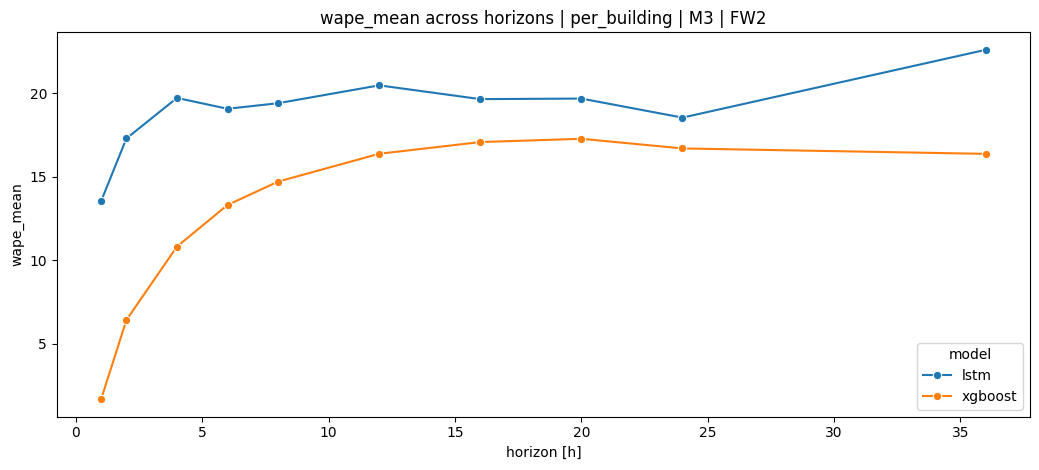

In [16]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_horizon_curves(
        summary_df,
        metric='wape_mean',
        regime=FOCUS_REGIME,
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        save_path=paths['plots'] / 'horizon_curve_wape.png',
    )


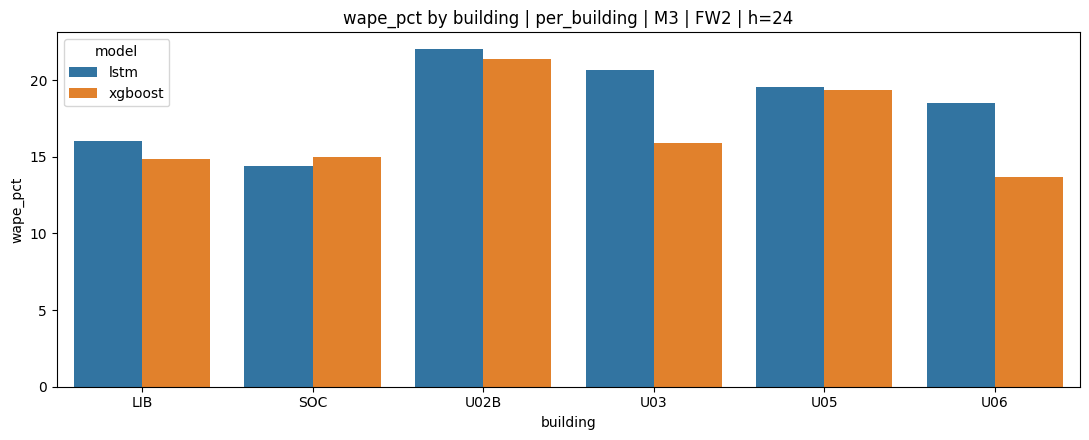

In [17]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_metric_bars(
        metrics_df,
        metric='wape_pct',
        regime=FOCUS_REGIME,
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        horizon_h=FOCUS_H,
        save_path=paths['plots'] / 'metric_bars_wape_h24.png',
    )


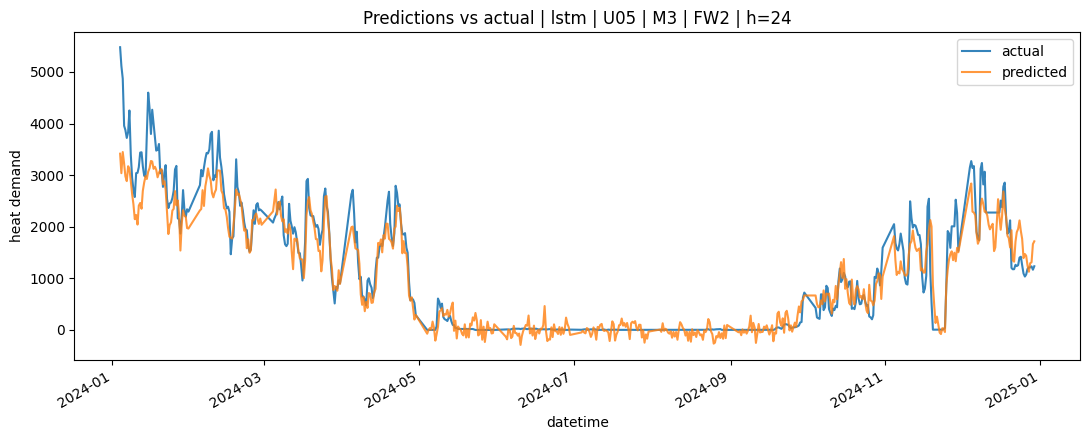

In [18]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_predictions_vs_actual(
        predictions_df,
        regime=FOCUS_REGIME,
        model_family='lstm',
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        horizon_h=FOCUS_H,
        building=FOCUS_BUILDING,
        save_path=paths['plots'] / 'lstm_predictions_vs_actual.png',
    )


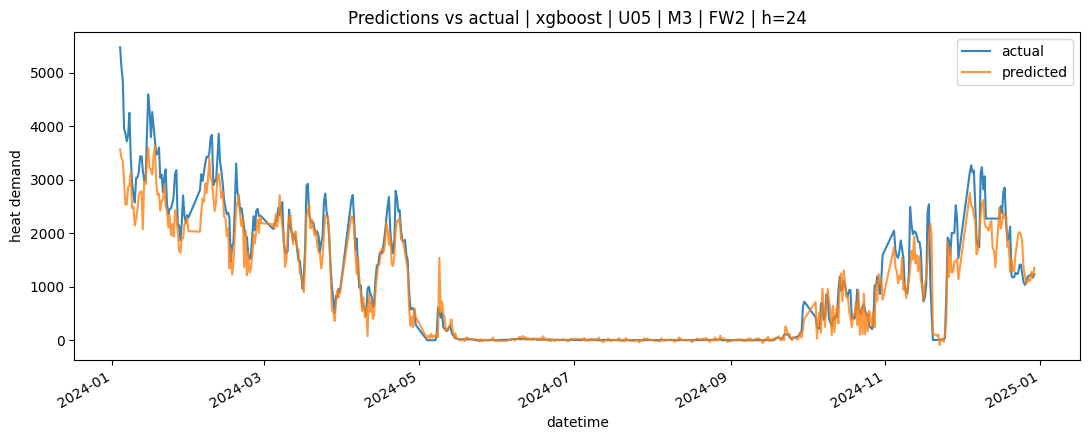

In [19]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_predictions_vs_actual(
        predictions_df,
        regime=FOCUS_REGIME,
        model_family='xgboost',
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        horizon_h=FOCUS_H,
        building=FOCUS_BUILDING,
        save_path=paths['plots'] / 'xgb_predictions_vs_actual.png',
    )


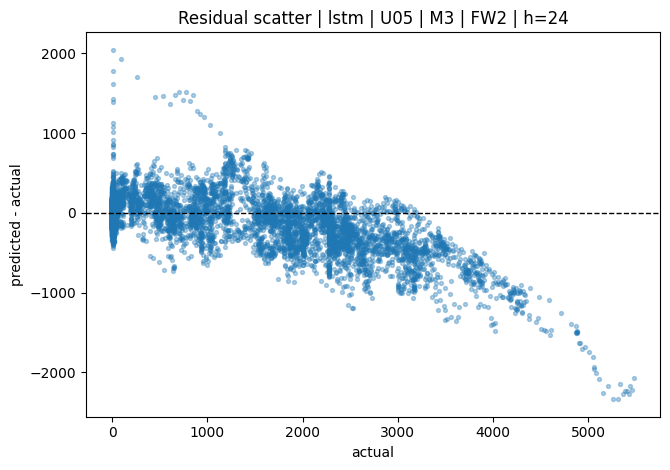

In [20]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_residual_scatter(
        predictions_df,
        regime=FOCUS_REGIME,
        model_family='lstm',
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        horizon_h=FOCUS_H,
        building=FOCUS_BUILDING,
        save_path=paths['plots'] / 'lstm_residual_scatter.png',
    )


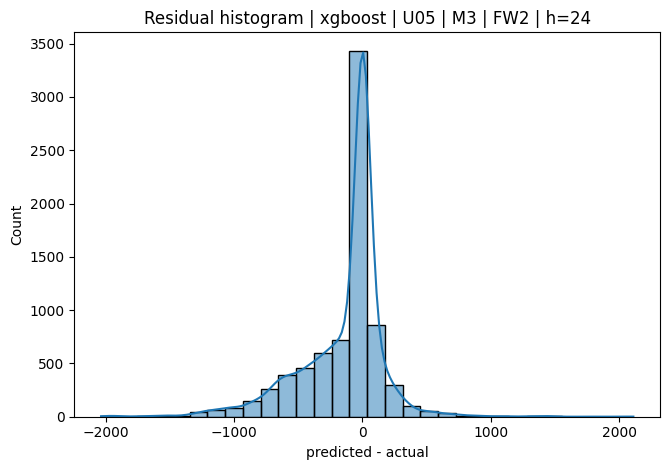

In [21]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_residual_histogram(
        predictions_df,
        regime=FOCUS_REGIME,
        model_family='xgboost',
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        horizon_h=FOCUS_H,
        building=FOCUS_BUILDING,
        save_path=paths['plots'] / 'xgb_residual_histogram.png',
    )


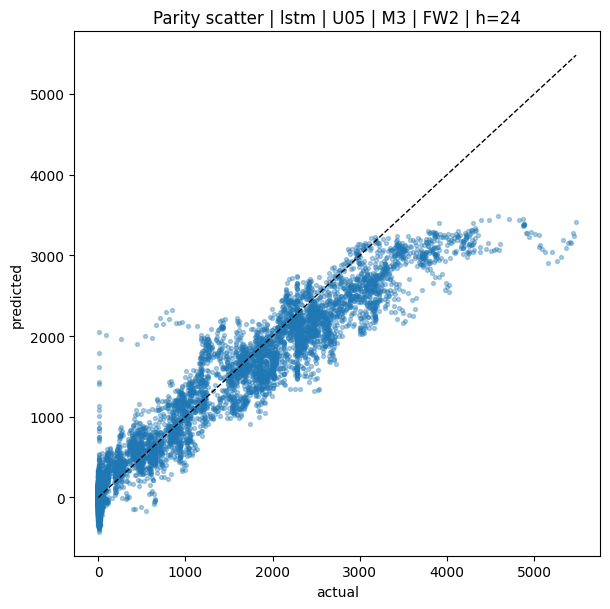

In [22]:
if not comparison_ready:
    display(Markdown('Load saved outputs first, or run the full matrix, before plotting.'))
else:
    mfc.plot_parity_scatter(
        predictions_df,
        regime=FOCUS_REGIME,
        model_family='lstm',
        mode=FOCUS_MODE,
        weather_mode=FOCUS_WEATHER,
        horizon_h=FOCUS_H,
        building=FOCUS_BUILDING,
        save_path=paths['plots'] / 'lstm_parity.png',
    )


In [23]:
if summary_df.empty:
    display(Markdown('No saved summary is available yet. Run the matrix first to generate thesis-ready tables.'))
else:
    thesis_focus = summary_df[
        (summary_df['regime'] == 'per_building')
        & (summary_df['weather_mode'] == 'FW2')
    ].copy()
    thesis_pivot = thesis_focus.pivot_table(
        index=['mode', 'horizon_h'],
        columns='model_family',
        values=['wape_mean', 'rmse_mean', 'r2_mean', 'mae_mean'],
    )
    display(Markdown('### Thesis-facing comparison table (`per_building`, `FW2`)'))
    display(thesis_pivot)

    if not metrics_df.empty:
        win_table = metrics_df[
            (metrics_df['regime'] == 'per_building')
            & (metrics_df['weather_mode'] == 'FW2')
        ].copy()
        win_table['is_best_wape'] = (
            win_table.groupby(['building', 'mode', 'horizon_h'])['wape_pct'].transform('min')
            == win_table['wape_pct']
        )
        display(Markdown('### Building-level win table (`per_building`, `FW2`)'))
        display(win_table.head(24))

    if not run_log_df.empty:
        failed_rows = run_log_df.loc[run_log_df['status'].astype(str).ne('ok')].copy()
        display(Markdown('### Non-OK run-log rows'))
        display(
            failed_rows.tail(24)
            if not failed_rows.empty
            else pd.DataFrame({'status': ['all completed rows currently marked ok']})
        )


### Thesis-facing comparison table (`per_building`, `FW2`)

mae_mean               r2_mean             rmse_mean  \
model_family          lstm     xgboost      lstm   xgboost        lstm   
mode horizon_h                                                           
M0   1            8.973464    1.153814  0.933760  0.993137   12.848388   
     2           21.879405    8.208364  0.911632  0.980528   30.871472   
     4           50.526110   29.026928  0.881407  0.954178   71.090071   
     6           73.870482   54.485453  0.884921  0.933756  105.593211   
     8          104.249448   82.478774  0.868110  0.918001  150.741086   
     12         152.561691  138.861323  0.865795  0.895893  215.186681   
     16         214.364317  193.508848  0.857747  0.885374  301.489325   
     20         262.553667  247.210952  0.853647  0.879514  375.269096   
     24         311.744712  286.555804  0.858908  0.885652  440.404998   
     36         527.422934  420.026912  0.832114  0.887077  733.402421   
M1   1            8.853141    1.228990  0.936010  0.993117   12.765295   
     2           20.375447    8.175439  0.915539  0.980556   29.195952   
     4           47.498035   29.102828  0.888848  0.953914   67.272526   
     6           75.941731   54.688489  0.879028  0.933746  108.381722   
     8          104.886074   82.561569  0.863534  0.918436  149.982804   
     12         148.373297  138.451513  0.868451  0.894782  212.140642   
     16         210.232592  191.952335  0.854911  0.883378  302.319936   
     20         257.823825  245.629532  0.858575  0.875966  367.330758   
     24         318.227644  282.681880  0.847978  0.884597  455.756254   
     36         509.173821  415.323025  0.838900  0.887383  711.668141   
M2   1            9.044507    1.333453  0.937186  0.993188   12.798251   
     2           22.065889    8.326293  0.911815  0.980895   30.834734   
     4           47.749382   29.314630  0.893648  0.954260   65.850018   
     6           79.512852   54.361055  0.875154  0.933577  111.647180   
     8          113.050487   81.094933  0.857759  0.918874  159.254182   
     12         163.249244  135.903443  0.852543  0.896462  231.343841   
     16         220.367517  188.589204  0.852263  0.887543  310.466063   
     20         278.718733  241.103892  0.839359  0.881869  402.495045   
     24         322.512693  280.691155  0.858315  0.886503  447.063379   
     36         544.574750  407.170648  0.823714  0.889773  755.882083   
M3   1            8.975702    1.236073  0.939930  0.993282   12.798608   
     2           23.561551    8.631166  0.905446  0.979948   32.917389   
     4           53.284182   29.252856  0.872327  0.954219   74.602786   
     6           79.273492   54.681768  0.878225  0.933716  110.446100   
     8          111.408857   81.125834  0.868547  0.918757  154.825158   
     12         172.240179  135.835287  0.843222  0.896056  242.230552   
     16         223.776805  189.029214  0.850539  0.885162  315.518399   
     20         276.697235  240.547633  0.850639  0.879968  385.792851   
     24         307.221912  278.487949  0.860103  0.886266  434.183490   
     36         568.967493  404.289295  0.805675  0.889114  788.041747   
M4   1            9.157396    1.175843  0.938849  0.993300   12.807192   
     2           22.860819    8.599551  0.906023  0.980131   32.147153   
     4           54.706799   29.341860  0.872730  0.954374   76.261736   
     6           79.719510   54.500329  0.872691  0.934052  111.935818   
     8          108.176987   81.235979  0.868991  0.919001  152.148065   
     12         170.419603  135.283247  0.849345  0.896457  246.078032   
     16         215.443162  188.568230  0.859788  0.885065  306.726553   
     20         273.539223  240.211552  0.858395  0.879929  378.542988   
     24         333.845015  278.932466  0.841624  0.885697  465.502953   
     36         495.994233  404.573201  0.850262  0.889743  687.265287   

                            wape_mean             
model_family       xgboost       lstm    xgb

### Building-level win table (`per_building`, `FW2`)

,regime,building,model_family,mode,weather_mode,horizon_h,rmse,wape_pct,r2,mae,n_test_rows,is_best_wape
40,per_building,LIB,lstm,M0,FW2,1,10.903629,9.565954,0.965775,7.471126,5561,False
41,per_building,LIB,xgboost,M0,FW2,1,5.251090,1.548525,0.992062,1.209417,5561,True
42,per_building,LIB,lstm,M0,FW2,2,27.467784,12.623520,0.945206,19.719891,5561,False
43,per_building,LIB,xgboost,M0,FW2,2,14.521751,4.956579,0.984685,7.742943,5561,True
44,per_building,LIB,lstm,M0,FW2,4,54.353727,12.681710,0.945466,39.618027,5561,False
45,per_building,LIB,xgboost,M0,FW2,4,40.470074,8.424146,0.969767,26.317276,5561,True
46,per_building,LIB,lstm,M0,FW2,6,86.704576,13.577912,0.937345,63.601815,5561,False
47,per_building,LIB,xgboost,M0,FW2,6,72.119430,10.536293,0.956651,49.354229,5561,True
48,per_building,LIB,lstm,M0,FW2,8,118.931015,14.116077,0.932679,88.107738,5561,False
49,per_building,LIB,xgboost,M0,FW2,8,106.597422,12.110165,0.945918,75.587519,5561,True


### Non-OK run-log rows

,status
0,all completed rows currently marked ok


## Presentation Add-On Views

These helpers use the saved notebook-12 CSV artifacts already on disk. They are meant for presentation work: short-window forecast comparisons, multi-horizon cumulative views, seasonal profile plots, and feature-set effect plots.


In [24]:
presentation_tables = mfp.build_model_intro_tables(
    config,
    architectures=mfc.ARCHITECTURES,
    xgb_fixed_params=mfc.XGB_FIXED_PARAMS,
    xgb_preset_lookup=mfc.XGB_PRESET_LOOKUP,
    mode_temporal_features=mfc.MODE_TEMPORAL_FEATURES,
    static_features_setb=mfc.LSTM_STATIC_FEATURES_SETB,
    summary_df=summary_df,
)

display(Markdown('### Model-family intro cards'))
display(presentation_tables['family_cards'])
display(Markdown('### Mode taxonomy cards'))
display(presentation_tables['mode_cards'])
display(Markdown('### Weather-mode taxonomy cards'))
display(presentation_tables['weather_mode_cards'])
display(Markdown('### Feature-block cards'))
display(presentation_tables['feature_blocks'])
if not presentation_tables['partial_highlights'].empty:
    display(Markdown('### Partial-run highlights from saved notebook-12 CSVs (`FW2`)'))
    display(presentation_tables['partial_highlights'])


### Model-family intro cards

,model_family,role,locked_id,architecture,training,what_it_does
0,lstm,sequence model,A6,L72 -> LSTM(64) -> Dense(16) -> 1,"Adam lr=0.001, batch=256, epochs=50, early_stop=3",Learns temporal state from ordered sequences a...
1,xgboost,gradient-boosted trees,P01_md3_lr003_mc5,"gbtree, n_estimators=2000, max_depth=3","lr=0.03, min_child_weight=5, subsample=0.8, co...",Learns nonlinear interactions in tabular featu...


### Mode taxonomy cards

,mode,dynamic_feature_count,uses_static_branch,description
0,M0,8,False,"Lean temporal core: observed heat, current wea..."
1,M1,9,False,M0 plus historical weather memory via the 24h ...
2,M2,14,False,M0 plus system / inertia features from space a...
3,M3,15,False,"M1 plus M2, still dynamic-only and still sourc..."
4,M4,15,True,M3 plus the static setB branch; future forecas...


### Weather-mode taxonomy cards

,weather_mode,description,future_weather_origin,operational_status
0,FW0,No future weather is appended.,none,baseline
1,FW1,Oracle future weather is created in memory fro...,oracle future weather,upper_bound_only
2,FW2,Forecast-like proxy future weather comes from ...,forecast-like proxy future weather,operational_analogue


### Feature-block cards

,feature_block,count,used_in,description
0,base_temporal_core,8,"M0, M1, M2, M3, M4","Observed heat, outdoor weather, and cyclic tim..."
1,system_inertia_block,6,"M2, M3, M4","Space / ventilation activity, deltaT, and low-..."
2,weather_memory_block,1,"M1, M3, M4",Longer temperature memory via the 24h rolling ...
3,static_setB_branch,20,M4,"Static building descriptors, topology, EHR pro..."


### Partial-run highlights from saved notebook-12 CSVs (`FW2`)

,regime,horizon_h,best_mode,best_family,best_wape_mean
0,per_building,1,M4,xgboost,1.624850
1,per_building,2,M2,xgboost,6.240274
2,per_building,4,M3,xgboost,10.817989
3,per_building,6,M4,xgboost,13.245596
4,per_building,8,M3,xgboost,14.702869
5,per_building,12,M4,xgboost,16.327737
6,per_building,16,M2,xgboost,17.022131
7,per_building,20,M4,xgboost,17.253858
8,per_building,24,M3,xgboost,16.687993
9,per_building,36,M3,xgboost,16.364262


In [25]:
SEASON_WINDOWS = mfp.season_windows(2024)
display(Markdown('### Suggested seasonal detail windows'))
display(
    pd.DataFrame(
        [
            {'season': season, 'start': window[0], 'end': window[1]}
            for season, window in SEASON_WINDOWS.items()
        ]
    )
)


### Suggested seasonal detail windows

,season,start,end
0,winter,2024-01-08,2024-01-14 23:00:00
1,spring,2024-04-08,2024-04-14 23:00:00
2,summer,2024-07-08,2024-07-14 23:00:00
3,fall,2024-10-07,2024-10-13 23:00:00


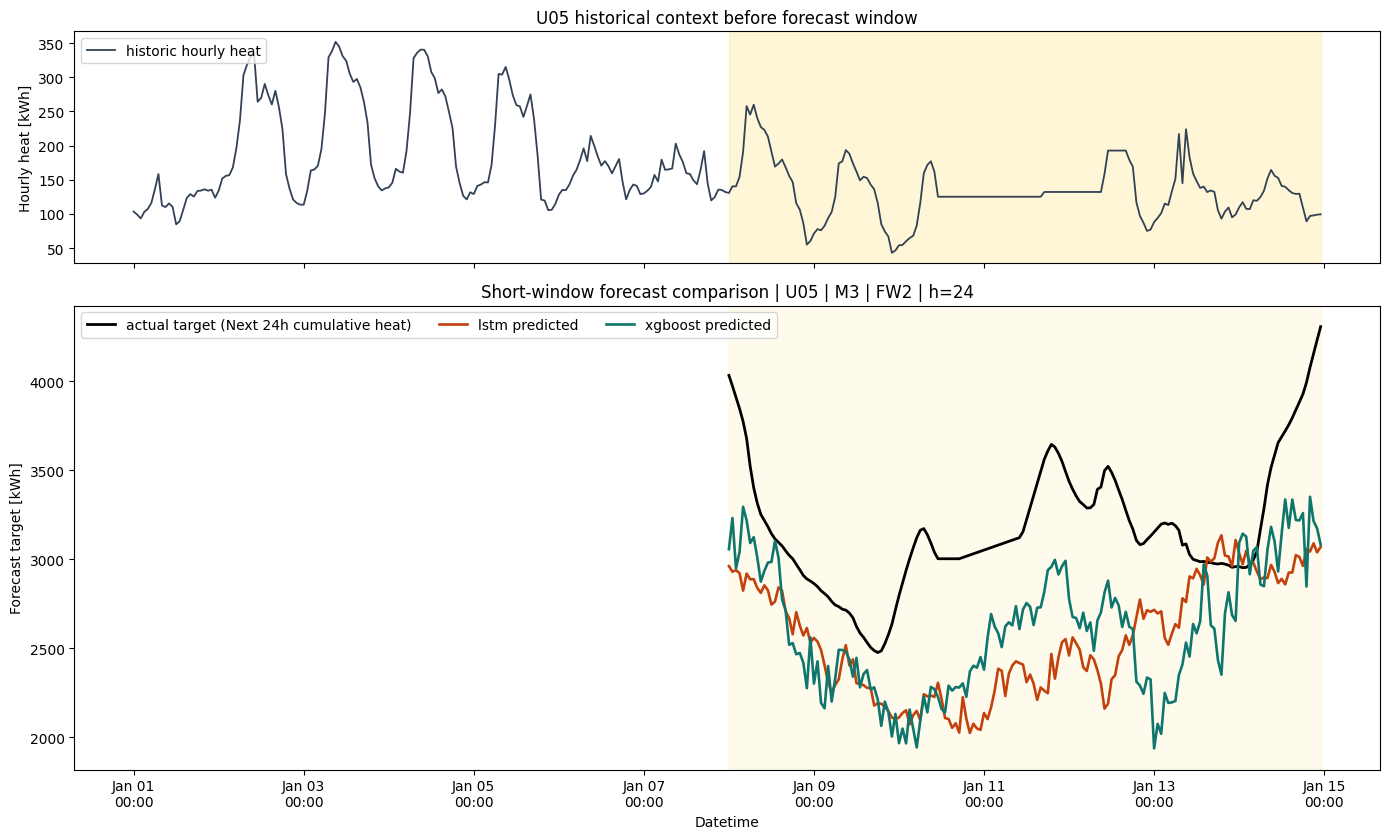

In [26]:
if predictions_df.empty:
    display(Markdown('Saved prediction artifacts are empty.'))
elif SEASON_WINDOWS is None:
    raise RuntimeError('Run the season-window cell first.')
else:
    win_start, win_end = SEASON_WINDOWS[PRESENT_SEASON]
    mfp.plot_short_window_family_comparison(
        predictions_df,
        base_frames,
        building=PRESENT_BUILDING,
        mode=PRESENT_MODE,
        weather_mode=PRESENT_WEATHER,
        horizon_h=PRESENT_HORIZON,
        start=win_start,
        end=win_end,
        save_path=paths['plots'] / 'presentation_family_window.png',
    )


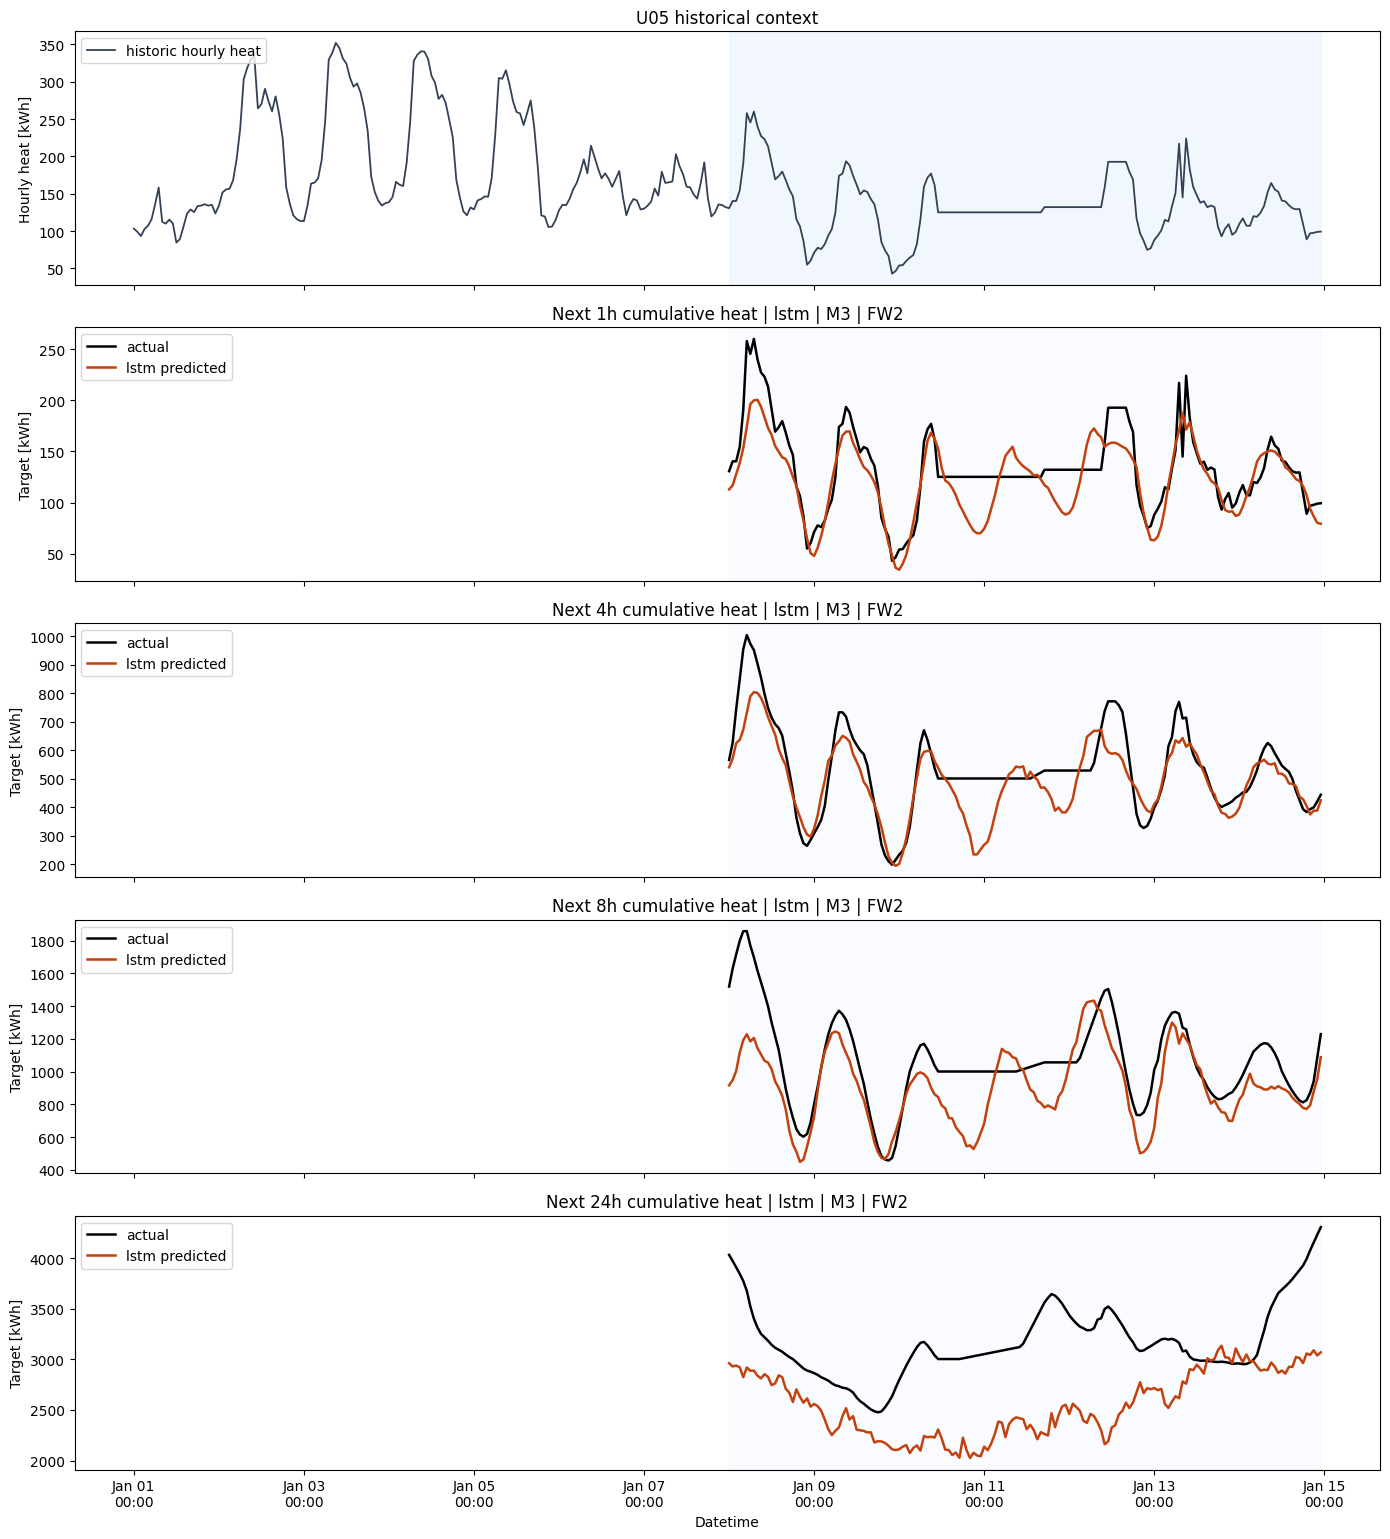

In [27]:
if predictions_df.empty:
    display(Markdown('Saved prediction artifacts are empty.'))
elif SEASON_WINDOWS is None:
    raise RuntimeError('Run the season-window cell first.')
else:
    win_start, win_end = SEASON_WINDOWS[PRESENT_SEASON]
    mfp.plot_multi_horizon_window(
        predictions_df,
        base_frames,
        building=PRESENT_BUILDING,
        model_family=PRESENT_FAMILY,
        mode=PRESENT_MODE,
        weather_mode=PRESENT_WEATHER,
        horizons=PRESENT_HORIZONS,
        start=win_start,
        end=win_end,
        save_path=paths['plots'] / 'presentation_multi_horizon_window.png',
    )


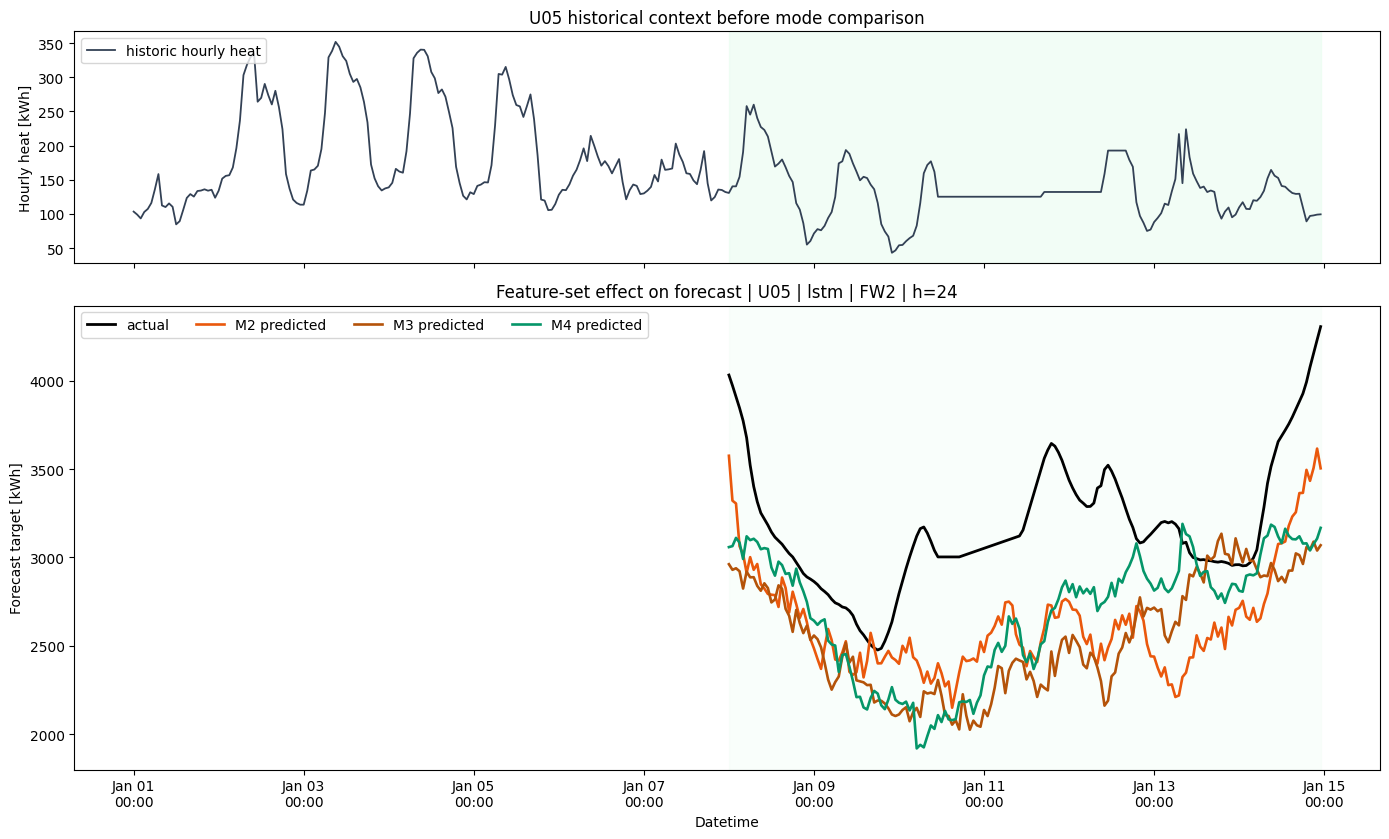

In [28]:
if predictions_df.empty:
    display(Markdown('Saved prediction artifacts are empty.'))
elif SEASON_WINDOWS is None:
    raise RuntimeError('Run the season-window cell first.')
else:
    win_start, win_end = SEASON_WINDOWS[PRESENT_SEASON]
    mfp.plot_feature_set_effect_window(
        predictions_df,
        base_frames,
        building=PRESENT_BUILDING,
        model_family=PRESENT_FAMILY,
        weather_mode=PRESENT_WEATHER,
        horizon_h=PRESENT_HORIZON,
        modes=PRESENT_FEATURE_EFFECT_MODES,
        start=win_start,
        end=win_end,
        save_path=paths['plots'] / 'presentation_feature_set_window.png',
    )


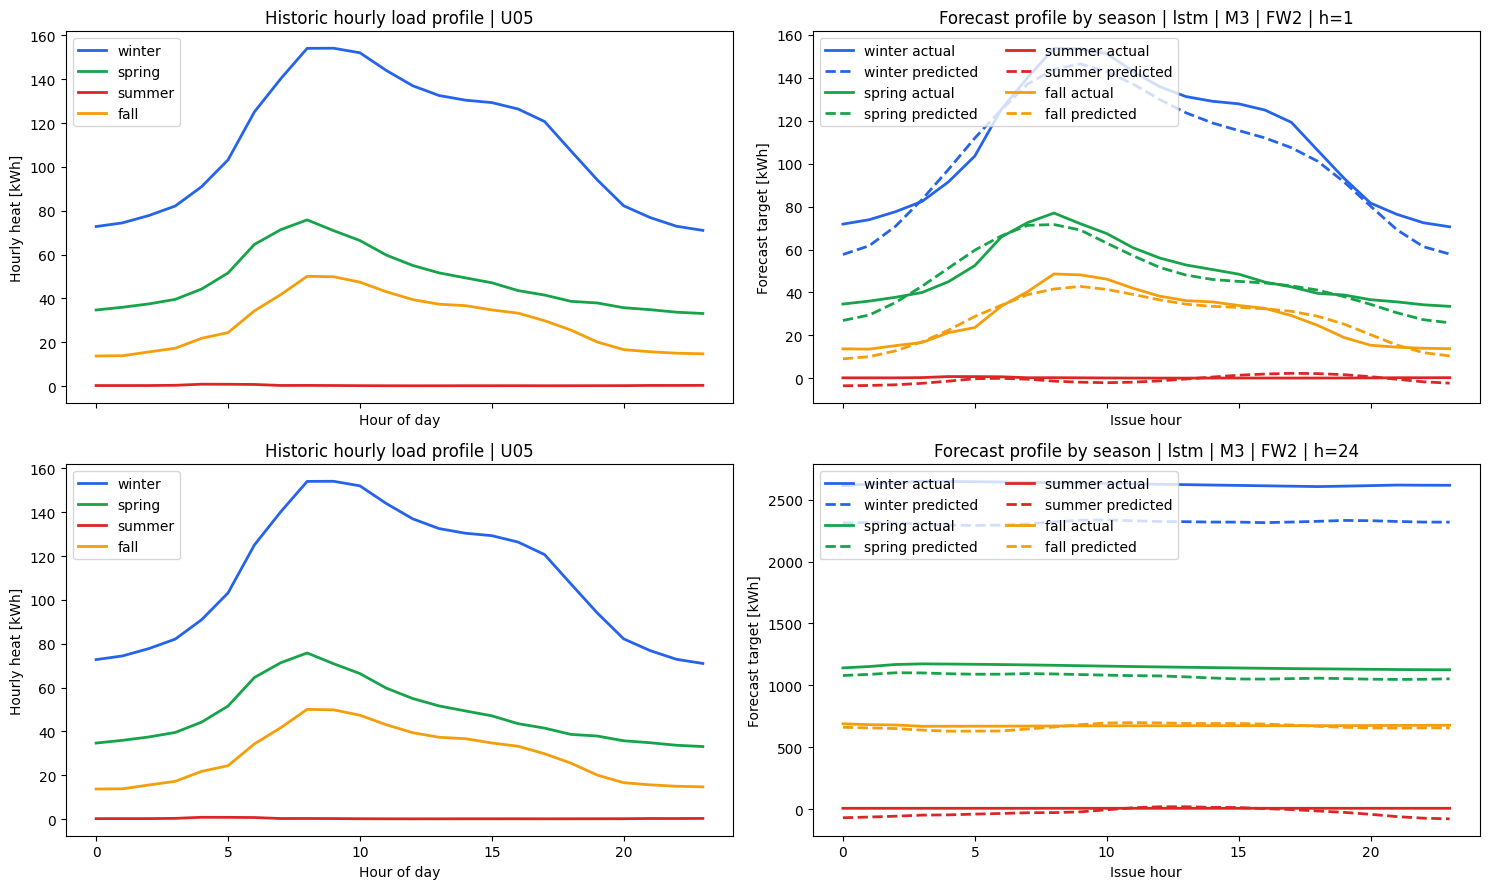

In [29]:
if predictions_df.empty:
    display(Markdown('Saved prediction artifacts are empty.'))
else:
    mfp.plot_historic_and_forecast_profiles_by_season(
        predictions_df,
        base_frames,
        building=PRESENT_BUILDING,
        model_family=PRESENT_FAMILY,
        mode=PRESENT_MODE,
        weather_mode=PRESENT_WEATHER,
        horizons=(1, 24),
        test_start=config.test_start,
        save_path=paths['plots'] / 'presentation_seasonal_profiles.png',
    )
